<a href="https://colab.research.google.com/github/enicaking/tfg-vae/blob/main/6_dscvi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5_coded_dSCVI.ipynb

# Discrete Error‑Correcting Uncoded VAE for scRNA‑seq (codedVAE + scVI)

This notebook replicates the core idea of the codedVAE paper (OpenReview `66P2ioAYY4`) in a **scVI** framework for single‑cell transcriptomics.

1. Load a toy heart atlas dataset (scvi‑tools).
2. Train a standard continuous‑latent scVI model.
3. Implement a discrete‑latent model that uses the ECC coded scheme
4. Compare latent spaces, reconstruction quality, and verify the correctness of the coded scheme.


# 0. Environment

## Libraries

In [2]:
import scvi

c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.8.0+cu128


In [1]:
import sys
print(sys.executable)

c:\Users\Justi\Documents\TFG\.venv\Scripts\python.exe


In [3]:
import os
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
# import umap # gives error so use scanpy.pl.umap

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import ModuleList
from torch.nn.functional import one_hot
from torch.distributions import Normal, RelaxedBernoulli, Bernoulli, kl_divergence
torch.set_float32_matmul_precision("high") # investigate what this helps to do

from __future__ import annotations

import logging
import warnings
from typing import TYPE_CHECKING

import collections
if TYPE_CHECKING:
    from collections.abc import Callable, Iterable
    from typing import Literal
    from torch.distributions import Distribution

logger = logging.getLogger(__name__)

import tempfile

In [4]:
import scvi
from scvi import REGISTRY_KEYS, settings
from scvi.model import SCVI
from scvi.model._utils import get_max_epochs_heuristic
from scvi.module import VAE
from scvi.model.base import (
    BaseModelClass,
    VAEMixin,
    RNASeqMixin,
    ArchesMixin,
    UnsupervisedTrainingMixin,
    BaseMinifiedModeModelClass,
)
from scvi.dataloaders import DataSplitter
from scvi.train import TrainingPlan, TrainRunner

from scvi.model._utils import _init_library_size
from scvi.model.base import UnsupervisedTrainingMixin
from scvi.model.utils import get_minified_adata_scrna

from scvi.data import AnnDataManager
from scvi.data.fields import (
    LayerField,
    NumericalObsField,
    CategoricalObsField,
    CategoricalJointObsField,
    NumericalJointObsField
)

from scvi.data._constants import ADATA_MINIFY_TYPE
from scvi.module._constants import MODULE_KEYS
from scvi.module.base import (
    BaseMinifiedModeModuleClass,
    EmbeddingModuleMixin,
    LossOutput,
    auto_move_data,
)
from scvi.utils import setup_anndata_dsp
from scvi.utils import unsupported_if_adata_minified
from scvi.nn._utils import ExpActivation

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)


Seed set to 0


Last run with scvi-tools version: 1.4.2


## Directory

In [ ]:
import os
from pathlib import Path
# from google.colab import drive
from datetime import datetime

In [6]:
# Working locally
from pathlib import Path
project_root = Path.cwd()
save_dir = project_root / "scvi_data"
os.makedirs(save_dir, exist_ok=True)
notebook_dir = project_root
os.makedirs(notebook_dir, exist_ok=True)
PLOTS_DIR = project_root / "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
DEFAULT_MODEL_NAME = "model_v1"
from model_comparison_utils import *  # Plotting functions
from utils import *                   # Helper functions
print(add_numbers(2, 3))

5


Naming conventions

`model_comparison_utils.py` defines MODELS_DIR / PLOTS_DIR under
`save_dir` / `notebook_dir` above, plus helpers so that every plot and
model checkpoint for a given experiment shares one consistent name and
never overwrites another experiment's files.

Workflow for a NEW model:
1. Pick a name once: `MODEL_NAME = register_model("uncoded_dscvi_v2")`
2. Save its checkpoint: `save_model(coded_model, MODEL_NAME)`
3. Every plotting call below takes `model_name=MODEL_NAME` and will save to
   `plots/<MODEL_NAME>_<plot_type>.png`, auto-suffixing (`_1`, `_2`, ...) if
   that exact filename already exists.


## Helper functions
from CodedVAE repository (utils.py)
1. dclamp adds numerical stability for reparametrization after sigmoid transformation
2. [sample_from_qz_given_x](https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/utils/sampling.py) implements the reparametrization to allow posterior/encoder q(m,z|x) to be calculated using the marginal q(z|x) = q(m|x)p(z|m). q(m|x) is the encoder and p(z|m) is the smoothing transformation.
3. `kl_div_bernoulli` custom implementation (based on [equation](https://statproofbook.github.io/P/bern-kl.html)) to compute the
KL divergence between two distributions.

In [7]:
def plot_path(plot_type: str,
              model_name: str = DEFAULT_MODEL_NAME,
              ext: str = "png",
              timestamp: bool = False) -> str:
    """
    Build a consistent, collision-free path for a plot file.

    e.g. plot_path("umap")                 -> plots/uncoded_dscvi_v1_umap.png
         plot_path("tsne", "my_model_v2")  -> plots/my_model_v2_tsne.png

    If a file with that exact name already exists, a numeric suffix is
    appended automatically (_1, _2, ...) so you never silently overwrite
    an earlier model's plot -- even if you forget to change model_name.
    """
    fname = f"{model_name}_{plot_type}"
    if timestamp:
        fname += f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

    candidate = os.path.join(PLOTS_DIR, f"{fname}.{ext}")
    counter = 1
    while os.path.exists(candidate):
        candidate = os.path.join(PLOTS_DIR, f"{fname}_{counter}.{ext}")
        counter += 1
    return candidate

In [8]:
# We need to be able to create the G matrix that we want
import torch

def build_repetition_G(bits_m, r):

    # Set the parameters
    num_rows = bits_m
    num_cols = bits_m * r # bits_c
    num_repetitions = int(num_cols/num_rows)

    # Create the repetition code matrix
    G = torch.zeros((num_rows, num_cols))
    for i in range(num_rows):
        # Set 10 ones in each row at consecutive positions
        G[i, i * num_repetitions:(i + 1) * num_repetitions] = 1

    # Matrix G is the generator matrix, used to encode the information vectors.
    # Matrix D is the transpose of G, used to decode the encoded vectors.
    # rep_matrices = {'G':G, 'H':G.T}

    return G

In [9]:
# def kl_div_bernoulli(q_probs, p_probs):
#     """
#     Compute KL Divergence D_KL(q|p) between two Bernoulli distributions.
#     """

#     # Extract probabilities if distribution objects are passed
#     if isinstance(q_probs, dist.Bernoulli):
#         q_probs = q_probs.probs
#     if isinstance(p_probs, dist.Bernoulli):
#         p_probs = p_probs.probs

#     # Clamp to avoid numerical instabilities
#     q_probs = torch.clamp(q_probs, min=1e-8, max=1 - 1e-8)
#     p_probs = torch.clamp(p_probs, min=1e-8, max=1 - 1e-8)

#     # Analytical formula: KL(q||p) = q*log(q/p) + (1-q)*log((1-q)/(1-p))
#     kl_div = (q_probs * (torch.log(q_probs) - torch.log(p_probs)) +
#               (1 - q_probs) * (torch.log(1 - q_probs) - torch.log(1 - p_probs)))

#     # Sum across latent dimensions
#     kl_div = torch.sum(kl_div, dim=1)

#     return kl_div

# 1. Data Preprocessing

In [10]:
# Load heart cell atlas subsampled
adata = scvi.data.heart_cell_atlas_subsampled()
print(adata)

INFO     File data/hca_subsampled_20k.h5ad already downloaded                                                      
AnnData object with n_obs × n_vars = 18641 × 26662
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'


In [11]:
adata.obs['region'].unique()

['LA', 'RV', 'RA', 'LV', 'AX', 'SP']
Categories (6, object): ['AX', 'LA', 'LV', 'RA', 'RV', 'SP']

In [12]:
adata.obs['donor'].nunique()

14

In [13]:
import scanpy as sc

In [14]:
# Basic filtering and HVG selection
sc.pp.filter_genes(adata, min_counts=3) # Minimum gene expressed in 3 cells
adata.layers["counts"] = adata.X.copy()
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")
adata = adata[:, adata.var.highly_variable].copy()
adata.shape

(18641, 2000)

# 2. Discrete scVI (DSCVI)

In [15]:
import torch
print(torch.cuda.is_available())      # True
print(torch.cuda.get_device_name(0))  # Tesla T4

True
NVIDIA GeForce RTX 4060 Laptop GPU


In [16]:
# from src.nn.modules import dclamp
# This is the function that takes m -> G -> z (i.e. p(z|c))

def modulate_words(words, beta=10):

    """
    Modulate words using the smoothing transformations.

    Parameters
        ----------
        words: torch.tensor
            Words to be modulated.
        beta : float
            Temperature term that controls the decay of the exponentials in the smoothing transformation. Default to 10.

        Returns
        -------
        z: torch.tensor
            Modulated words.
    """

    # Here we are modulating C using the exponentials
    # Obtain sample from p(z|c) in the coded case -> we fix the code word (it was previously sampled from q(c|x,C))
    # c_sample has shape [N, n_bits, n_samples] -> we obtain a sample from p(z|c) for each sampled word c

    # Sanity check
    assert torch.all(torch.logical_or(words == 0, words == 1)), "Invalid word encountered. All words should be binary vectors."

    epsilon = 1e-6

    # Create masks with the sampled word to select the bit samples
    not_c_sample = torch.logical_not(words).type(torch.float32) # shape [N, n_bits, n_samples], ones where ci=0

    # Auxiliar variable
    ones = torch.ones((words.shape)).to(words.device)

    # Sample from U(0,1)
    rho = torch.rand(words.shape).to(words.device)

    # Sample from F^(-1)(zi|ci=0)
    z0 = -(1/beta)*torch.log((ones-rho*(ones-ones*torch.exp(-beta)))+epsilon)
    # Apply ci=0 mask
    z0 = z0*not_c_sample

    # Sample from F^(-1)(zi|ci=1)
    z1 = (1/beta)*torch.log((rho*(ones-ones*torch.exp(-beta) + ones*torch.exp(-beta)))+epsilon) + 1
    # Apply ci=1 mask
    z1 = z1*words

    z = z0+z1

    # Sanity check
    assert torch.any(torch.isinf(z))==False, "Invalid z_sample value (inf)."
    assert torch.any(torch.isnan(z))==False, "Invalid z_sample value (nan)."

    return z  # shape [N, n_bits, n_samples]

## Encoder

- Change encoder output (Add sigmoid and dclamp like in source code)
  - sigmoid in `__init__`
  - dclamp in `forward`
- If coded, implement torch pooling

In [17]:
# Encoder
import collections
from collections.abc import Callable, Iterable
from typing import Literal

import torch
from torch import nn
from torch.distributions import Normal
from torch.distributions import Normal, RelaxedBernoulli, Bernoulli, kl_divergence
from torch.nn import ModuleList

from scvi.nn._utils import ExpActivation


def _identity(x):
    return x


class FCLayers(nn.Module):
    """A helper class to build fully-connected layers for a neural network.

    Parameters
    ----------
    n_in
        The dimensionality of the input
    n_out
        The dimensionality of the output
    n_cat_list
        A list containing, for each category of interest,
        the number of categories. Each category will be
        included using a one-hot encoding.
    n_cont
        The dimensionality of the continuous covariates
    n_layers
        The number of fully-connected hidden layers
    n_hidden
        The number of nodes per hidden layer
    dropout_rate
        Dropout rate to apply to each of the hidden layers
    use_batch_norm
        Whether to have `BatchNorm` layers or not
    use_layer_norm
        Whether to have `LayerNorm` layers or not
    use_activation
        Whether to have layer activation or not
    bias
        Whether to learn bias in linear layers or not
    inject_covariates
        Whether to inject covariates in each layer, or just the first (default).
    activation_fn
        Which activation function to use
    """

    def __init__(
        self,
        n_in: int,
        n_out: int,
        n_cat_list: Iterable[int] = None,
        n_cont: int = 0,
        n_layers: int = 1,
        n_hidden: int = 128,
        dropout_rate: float = 0.1,
        use_batch_norm: bool = True,
        use_layer_norm: bool = False,
        use_activation: bool = True,
        bias: bool = True,
        inject_covariates: bool = True,
        activation_fn: nn.Module = nn.ReLU,
    ):
        super().__init__()
        self.inject_covariates = inject_covariates
        layers_dim = [n_in] + (n_layers - 1) * [n_hidden] + [n_out]

        if n_cat_list is not None:
            # n_cat = 1 will be ignored
            self.n_cat_list = [n_cat if n_cat > 1 else 0 for n_cat in n_cat_list]
        else:
            self.n_cat_list = []

        self.n_cov = n_cont + sum(self.n_cat_list)

        self.fc_layers = nn.Sequential(
            collections.OrderedDict(
                [
                    (
                        f"Layer {i}",
                        nn.Sequential(
                            nn.Linear(
                                n_in + self.n_cov * self.inject_into_layer(i),
                                n_out,
                                bias=bias,
                            ),
                            # non-default params come from defaults in the original Tensorflow
                            # implementation
                            nn.BatchNorm1d(n_out, momentum=0.01, eps=0.001)
                            if use_batch_norm
                            else None,
                            nn.LayerNorm(n_out, elementwise_affine=False)
                            if use_layer_norm
                            else None,
                            activation_fn() if use_activation else None,
                            nn.Dropout(p=dropout_rate) if dropout_rate > 0 else None,
                        ),
                    )
                    for i, (n_in, n_out) in enumerate(
                        zip(layers_dim[:-1], layers_dim[1:], strict=True)
                    )
                ]
            )
        )

    def inject_into_layer(self, layer_num) -> bool:
        """Helper to determine if covariates should be injected."""
        user_cond = layer_num == 0 or (layer_num > 0 and self.inject_covariates)
        return user_cond

    def set_online_update_hooks(self, hook_first_layer=True):
        """Set online update hooks."""
        self.hooks = []

        def _hook_fn_weight(grad):
            categorical_dims = sum(self.n_cat_list)
            new_grad = torch.zeros_like(grad)
            if categorical_dims > 0:
                new_grad[:, -categorical_dims:] = grad[:, -categorical_dims:]
            return new_grad

        def _hook_fn_zero_out(grad):
            return grad * 0

        for i, layers in enumerate(self.fc_layers):
            for layer in layers:
                if i == 0 and not hook_first_layer:
                    continue
                if isinstance(layer, nn.Linear):
                    if self.inject_into_layer(i):
                        w = layer.weight.register_hook(_hook_fn_weight)
                    else:
                        w = layer.weight.register_hook(_hook_fn_zero_out)
                    self.hooks.append(w)
                    b = layer.bias.register_hook(_hook_fn_zero_out)
                    self.hooks.append(b)

    def forward(self, x: torch.Tensor, *cat_list: int, cont: torch.Tensor | None = None):
        """Forward computation on ``x``.

        Parameters
        ----------
        x
            tensor of values with shape ``(n_in,)``
        cat_list
            list of category membership(s) for this sample
        cont
            tensor of continuous covariates with shape ``(n_cont,)``

        Returns
        -------
        :class:`torch.Tensor`
            tensor of shape ``(n_out,)``
        """
        one_hot_cat_list = []  # for generality in this list many idxs useless.
        cont_list = [cont] if cont is not None else []
        cat_list = cat_list or []

        if len(self.n_cat_list) > len(cat_list):
            raise ValueError("nb. categorical args provided doesn't match init. params.")
        for n_cat, cat in zip(self.n_cat_list, cat_list, strict=False):
            if n_cat and cat is None:
                raise ValueError("cat not provided while n_cat != 0 in init. params.")
            if n_cat > 1:  # n_cat = 1 will be ignored - no additional information
                if cat.size(1) != n_cat:
                    one_hot_cat = nn.functional.one_hot(cat.squeeze(-1), n_cat)
                else:
                    one_hot_cat = cat  # cat has already been one_hot encoded
                one_hot_cat_list += [one_hot_cat]
        cov_list = cont_list + one_hot_cat_list
        for i, layers in enumerate(self.fc_layers):
            for layer in layers:
                if layer is not None:
                    if isinstance(layer, nn.BatchNorm1d):
                        if x.dim() == 3:
                            if (
                                x.device.type == "mps"
                            ):  # TODO: remove this when MPS supports for loop.
                                x = torch.cat(
                                    [(layer(slice_x.clone())).unsqueeze(0) for slice_x in x], dim=0
                                )
                            else:
                                x = torch.cat(
                                    [layer(slice_x).unsqueeze(0) for slice_x in x], dim=0
                                )
                        else:
                            x = layer(x)
                    else:
                        if isinstance(layer, nn.Linear) and self.inject_into_layer(i):
                            if x.dim() == 3:
                                cov_list_layer = [
                                    o.unsqueeze(0).expand((x.size(0), o.size(0), o.size(1)))
                                    for o in cov_list
                                ]
                            else:
                                cov_list_layer = cov_list
                            x = torch.cat((x, *cov_list_layer), dim=-1)
                        x = layer(x)
        return x


import torch
import torch.nn as nn
from torch.distributions import Bernoulli, kl_divergence

def _identity(x):
    return x

class Encoder(nn.Module):
    """
    Encode data into a latent space of n_output dimensions.

    Supports:
    - "normal" : Gaussian (mean, variance)
    - "ln"     : Log‑Normal (softmaxed)
    - "ber"    : Bernoulli, using custom reparameterization trick (inverse cdf beta smoothing)
    """

    def __init__(
        self,
        n_input: int,
        n_output: int,
        n_cat_list: Iterable[int] = None,
        n_layers: int = 1,
        n_hidden: int = 128,
        dropout_rate: float = 0.1,
        distribution: str = "ber",
        coded_key: bool = False,
        G = None,
        var_eps: float = 1e-4,
        var_activation: Callable | None = None,
        return_dist: bool = False,
        beta: float = 10.0, # reparameterization temperature parameter
        **kwargs,
    ):
        super().__init__()

        self.distribution = distribution
        self.coded_key = coded_key
        self.var_eps = var_eps
        self.return_dist = return_dist
        self.beta = beta
        if G is not None:
          self.register_buffer("G", G)
          self.register_buffer("H", G.T.contiguous()) # why contiguous?
        else:
          self.G=None
          self.H=None
        # self.G = G
        # if G is not None:
        #   self.H = G.T
        # self.device = 'cpu' # change in the future? placeholder

        # Shared encoder
        self.encoder = FCLayers(
            n_in=n_input,
            n_out=n_hidden,
            n_cat_list=n_cat_list,
            n_layers=n_layers,
            n_hidden=n_hidden,
            dropout_rate=dropout_rate,
            **kwargs,
        )

        # Mean / logits head
        self.mean_encoder = nn.Linear(n_hidden, n_output)

        # Variance head only for continuous distributions
        if distribution in ["normal", "ln"]:
            self.var_encoder = nn.Linear(n_hidden, n_output)
            self.var_activation = torch.exp if var_activation is None else var_activation
        else: # Bernoulli distribution output does not have variance metric
            self.var_encoder = None
            self.var_activation = None

        # Transformations for non‑Normal outputs (only used for "ln")
        if distribution == "ln":
            self.z_transformation = nn.Softmax(dim=-1)
        else:
            self.z_transformation = _identity

    def forward(self, x: torch.Tensor, *cat_list: int):
        """
        Forward pass.

        For distribution="ber":
            - Computes logits from mean_encoder.
            - Converts to probabilities (qi) via sigmoid.
            - Uses your sample_from_qz_given_x to obtain a continuous sample (reparameterized).
            - If return_dist=True, returns (Bernoulli distribution, latent_sample).
            - Else returns (logits, probs, latent_sample).
        """
        q = self.encoder(x, *cat_list)

        if self.distribution == "ber":
            logits = self.mean_encoder(q)                     # (batch, n_latent) or (batch, n_code)
            qi = torch.sigmoid(logits)                        # probabilities in (0,1)
            qi = dclamp(qi, 1e-4, 1-1e-4)
            if torch.isnan(logits).any() or torch.isinf(logits).any():
              print(f"Bad logits detected: min={logits.min()}, max={logits.max()}")

            if not self.coded_key: # UNCODED CASE
              # Use your reparameterization function to get a sample
              # (we call it with n_samples=1 to get a single sample per batch element)
              latent = sample_from_qz_given_x(qi, beta=torch.tensor(self.beta), n_samples=1)
              latent = latent.squeeze(-1) # (batch, n_latent)
              q_m = qi                    # n_latent -dim, same tensor, has gradients
              return qi, q_m, latent

            else: # CODED CASE
              # Use your reparameterization function to get a sample
              # (we call it with n_samples=1 to get a single sample per batch element)

              # ENCODER_OUT IS p(c|x)
              # Soft decoding: obtain the marginals of the information bits

              logpm1 = torch.matmul(torch.log(qi), self.H)
              logpm0 = torch.matmul(torch.log(1-qi), self.H)

              log_marginals = torch.stack((logpm0, logpm1), dim=2) # THIS IS p(m|x)
              log_marginals_norm = log_marginals - torch.logsumexp(log_marginals, dim=-1, keepdim=True)
              p_m_given_x = torch.exp(log_marginals_norm[:,:,1]) # (batch, n_latent)

              # Introduce code structure to get p(z|x)
              qc = torch.matmul(torch.exp(p_m_given_x), self.G)
              qc = dclamp(qc, 1e-4, 1 - 1e-4) # Numerical stability

              # Modulate c to obtain z
              latent = sample_from_qz_given_x(qc, beta=torch.tensor(self.beta), n_samples=1)
              latent = latent.squeeze(-1)          # (batch, n_latent, 1)  --> (batch, n_latent)

              return qc, p_m_given_x, latent

            # # Create a Bernoulli distribution for KL divergence (optional)
            # dist = Bernoulli(probs=qi)
            # # Should maybe rethink this, return qi and empty variable no matter what ?

            # if self.return_dist:
            #     return dist, latent
            # else:
            #     return qi, latent

        else:
            # Normal or Log‑Normal (unchanged)
            q_m = self.mean_encoder(q)
            q_v = self.var_activation(self.var_encoder(q)) + self.var_eps
            dist = Normal(q_m, q_v.sqrt())
            latent = self.z_transformation(dist.rsample())

            if self.return_dist:
                return dist, latent
            else:
                return q_m, q_v, latent


## DSCVIModule

Changes made
- Added `self.beta` temperature term at default value 10. Beta is the inverse temperature term of Gumbel-Softmax smoothing. The higher it is, the stricter (values go to 0 or 1 more easily)
- Added `'ber'` as an option to `self.latent_distribution` for uncoded DVAE++

Important functions from `coded_vae.py`
- [forward()](https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/coded_vae.py#L127)
- [generate()](https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/coded_vae.py#L324)

Functions native to scVI
- get_latent_representation() in UncodedSCVI()
- loss() in UncodedSCVIModule()
- sample() in UncodedSCVIModule()
- generative() in UncodedSCVIModule()
- _regular_inference() in UncodedSCVIModule()


NN architecture links
- [Encoder](https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/nn/encoder.py) (dcgan)
- [Decoder](https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/nn/decoder.py) (cnnskip)

In [18]:
class DSCVIModule(EmbeddingModuleMixin, BaseMinifiedModeModuleClass):
    """Variational auto-encoder :cite:p:`Lopez18`.

    Parameters
    ----------
    n_input
        Number of input features.
    n_batch
        Number of batches. If ``0``, no batch correction is performed.
    n_labels
        Number of labels.
    n_hidden
        Number of nodes per hidden layer. Passed into :class:`~scvi.nn.Encoder` and
        :class:`~scvi.nn.DecoderSCVI`.
    n_latent
        Dimensionality of the latent space.
    n_layers
        Number of hidden layers. Passed into :class:`~scvi.nn.Encoder` and
        :class:`~scvi.nn.DecoderSCVI`.
    n_continuous_cov
        Number of continuous covariates.
    n_cats_per_cov
        A list of integers containing the number of categories for each categorical covariate.
    dropout_rate
        Dropout rate. Passed into :class:`~scvi.nn.Encoder` but not :class:`~scvi.nn.DecoderSCVI`.
    dispersion
        Flexibility of the dispersion parameter when ``gene_likelihood`` is either ``"nb"`` or
        ``"zinb"``. One of the following:

        * ``"gene"``: parameter is constant per gene across cells.
        * ``"gene-batch"``: parameter is constant per gene per batch.
        * ``"gene-label"``: parameter is constant per gene per label.
        * ``"gene-cell"``: parameter is constant per gene per cell.
    log_variational
        If ``True``, use :func:`~torch.log1p` on input data before encoding for numerical stability
        (not normalization).
    gene_likelihood
        Distribution to use for reconstruction in the generative process. One of the following:

        * ``"nb"``: :class:`~scvi.distributions.NegativeBinomial`.
        * ``"zinb"``: :class:`~scvi.distributions.ZeroInflatedNegativeBinomial`.
        * ``"poisson"``: :class:`~scvi.distributions.Poisson`.
        * ``"normal"``: :class:`~torch.distributions.Normal`.
    latent_distribution
        Distribution to use for the latent space. One of the following:

        * ``"normal"``: isotropic normal.
        * ``"ln"``: logistic normal with normal params N(0, 1).
    encode_covariates
        If ``True``, covariates are concatenated to gene expression prior to passing through
        the encoder(s). Else, only gene expression is used.
    deeply_inject_covariates
        If ``True`` and ``n_layers > 1``, covariates are concatenated to the outputs of hidden
        layers in the encoder(s) (if ``encoder_covariates`` is ``True``) and the decoder prior to
        passing through the next layer.
    batch_representation
        ``EXPERIMENTAL`` Method for encoding batch information. One of the following:

        * ``"one-hot"``: represent batches with one-hot encodings.
        * ``"embedding"``: represent batches with continuously-valued embeddings using
          :class:`~scvi.nn.Embedding`.

        Note that batch representations are only passed into the encoder(s) if
        ``encode_covariates`` is ``True``.
    use_batch_norm
        Specifies where to use :class:`~torch.nn.BatchNorm1d` in the model. One of the following:

        * ``"none"``: don't use batch norm in either encoder(s) or decoder.
        * ``"encoder"``: use batch norm only in the encoder(s).
        * ``"decoder"``: use batch norm only in the decoder.
        * ``"both"``: use batch norm in both encoder(s) and decoder.

        Note: if ``use_layer_norm`` is also specified, both will be applied (first
        :class:`~torch.nn.BatchNorm1d`, then :class:`~torch.nn.LayerNorm`).
    use_layer_norm
        Specifies where to use :class:`~torch.nn.LayerNorm` in the model. One of the following:

        * ``"none"``: don't use layer norm in either encoder(s) or decoder.
        * ``"encoder"``: use layer norm only in the encoder(s).
        * ``"decoder"``: use layer norm only in the decoder.
        * ``"both"``: use layer norm in both encoder(s) and decoder.

        Note: if ``use_batch_norm`` is also specified, both will be applied (first
        :class:`~torch.nn.BatchNorm1d`, then :class:`~torch.nn.LayerNorm`).
    use_size_factor_key
        If ``True``, use the :attr:`~anndata.AnnData.obs` column as defined by the
        ``size_factor_key`` parameter in the model's ``setup_anndata`` method as the scaling
        factor in the mean of the conditional distribution. Takes priority over
        ``use_observed_lib_size``.
    use_observed_lib_size
        If ``True``, use the observed library size for RNA as the scaling factor in the mean of the
        conditional distribution.
    extra_payload_autotune
        If ``True``, will return extra matrices in the loss output to be used during autotune
    library_log_means
        :class:`~numpy.ndarray` of shape ``(1, n_batch)`` of means of the log library sizes that
        parameterize the prior on library size if ``use_size_factor_key`` is ``False`` and
        ``use_observed_lib_size`` is ``False``.
    library_log_vars
        :class:`~numpy.ndarray` of shape ``(1, n_batch)`` of variances of the log library sizes
        that parameterize the prior on library size if ``use_size_factor_key`` is ``False`` and
        ``use_observed_lib_size`` is ``False``.
    var_activation
        Callable used to ensure positivity of the variance of the variational distribution. Passed
        into :class:`~scvi.nn.Encoder`. Defaults to :func:`~torch.exp`.
    extra_encoder_kwargs
        Additional keyword arguments passed into :class:`~scvi.nn.Encoder`.
    extra_decoder_kwargs
        Additional keyword arguments passed into :class:`~scvi.nn.DecoderSCVI`.
    batch_embedding_kwargs
        Keyword arguments passed into :class:`~scvi.nn.Embedding` if ``batch_representation`` is
        set to ``"embedding"``.

    """

    def __init__(
        self,
        n_input: int,
        n_batch: int = 0,
        n_labels: int = 0,
        n_hidden: int = 128,
        n_latent: int = 10,
        n_code: int = 50,
        G = None, # GENERATOR MATRIX G
        n_layers: int = 1,
        n_continuous_cov: int = 0,
        n_cats_per_cov: list[int] | None = None,
        dropout_rate: float = 0.1,
        beta: int = 10, # ADD TEMPERATURE VARIABLE
        dispersion: Literal["gene", "gene-batch", "gene-label", "gene-cell"] = "gene",
        log_variational: bool = True,
        gene_likelihood: Literal["zinb", "nb", "poisson"] = "zinb",
        latent_distribution: Literal["normal", "ln", "ber"] = "ber", # ADD DVAE OPTION
        coded_key: bool = False, # ADD CODED / UNCODED FLAG
        encode_covariates: bool = False,
        deeply_inject_covariates: bool = True,
        batch_representation: Literal["one-hot", "embedding"] = "one-hot",
        use_batch_norm: Literal["encoder", "decoder", "none", "both"] = "both",
        use_layer_norm: Literal["encoder", "decoder", "none", "both"] = "none",
        use_size_factor_key: bool = False,
        use_observed_lib_size: bool = True,
        extra_payload_autotune: bool = False,
        library_log_means: np.ndarray | None = None,
        library_log_vars: np.ndarray | None = None,
        var_activation: Callable[[torch.Tensor], torch.Tensor] = None,
        extra_encoder_kwargs: dict | None = None,
        extra_decoder_kwargs: dict | None = None,
        batch_embedding_kwargs: dict | None = None,
    ):
        from scvi.nn import DecoderSCVI
        # https://docs.scvi-tools.org/en/stable/api/reference/scvi.nn.Encoder.html

        super().__init__()

        self.dispersion = dispersion
        self.n_latent = n_latent
        self.beta = beta
        self.log_variational = log_variational
        self.gene_likelihood = gene_likelihood
        self.n_batch = n_batch
        self.n_labels = n_labels

        # MODIFIED ATTRIBUTES
        self.latent_distribution = latent_distribution
        self.coded_key = coded_key
        self.G = G # Not used here, only by encoder

        # METADATA
        self.encode_covariates = encode_covariates
        self.use_size_factor_key = use_size_factor_key
        self.use_observed_lib_size = use_size_factor_key or use_observed_lib_size
        self.extra_payload_autotune = extra_payload_autotune

        if not self.use_observed_lib_size:
            if library_log_means is None or library_log_vars is None:
                raise ValueError(
                    "If not using observed_lib_size, "
                    "must provide library_log_means and library_log_vars."
                )

            self.register_buffer("library_log_means", torch.from_numpy(library_log_means).float())
            self.register_buffer("library_log_vars", torch.from_numpy(library_log_vars).float())

        if self.dispersion == "gene":
            self.px_r = torch.nn.Parameter(torch.randn(n_input))
        elif self.dispersion == "gene-batch":
            self.px_r = torch.nn.Parameter(torch.randn(n_input, n_batch))
        elif self.dispersion == "gene-label":
            self.px_r = torch.nn.Parameter(torch.randn(n_input, n_labels))
        elif self.dispersion == "gene-cell":
            pass
        else:
            raise ValueError(
                "`dispersion` must be one of 'gene', 'gene-batch', 'gene-label', 'gene-cell'."
            )

        self.batch_representation = batch_representation
        if self.batch_representation == "embedding":
            self.init_embedding(REGISTRY_KEYS.BATCH_KEY, n_batch, **(batch_embedding_kwargs or {}))
            batch_dim = self.get_embedding(REGISTRY_KEYS.BATCH_KEY).embedding_dim
        elif self.batch_representation != "one-hot":
            raise ValueError("`batch_representation` must be one of 'one-hot', 'embedding'.")

        use_batch_norm_encoder = use_batch_norm == "encoder" or use_batch_norm == "both"
        use_batch_norm_decoder = use_batch_norm == "decoder" or use_batch_norm == "both"
        use_layer_norm_encoder = use_layer_norm == "encoder" or use_layer_norm == "both"
        use_layer_norm_decoder = use_layer_norm == "decoder" or use_layer_norm == "both"

        n_input_encoder = n_input + n_continuous_cov * encode_covariates
        z_encoder_out = n_code if coded_key else n_latent
        if self.batch_representation == "embedding":
            n_input_encoder += batch_dim * encode_covariates
            cat_list = list([] if n_cats_per_cov is None else n_cats_per_cov)
        else:
            cat_list = [n_batch] + list([] if n_cats_per_cov is None else n_cats_per_cov)

        encoder_cat_list = cat_list if encode_covariates else None
        _extra_encoder_kwargs = extra_encoder_kwargs or {}
        self.z_encoder = Encoder(
            n_input_encoder,
            z_encoder_out,
            n_cat_list=encoder_cat_list,
            n_layers=n_layers,
            n_hidden=n_hidden,
            dropout_rate=dropout_rate,
            distribution=latent_distribution,
            coded_key=coded_key,
            G=G,
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_encoder,
            use_layer_norm=use_layer_norm_encoder,
            var_activation=var_activation,
            return_dist=True,
            **_extra_encoder_kwargs,
        )
        # l encoder goes from n_input-dimensional data to 1-d library size
        self.l_encoder = Encoder(
            n_input_encoder,
            1,
            n_layers=1,
            n_cat_list=encoder_cat_list,
            n_hidden=n_hidden,
            dropout_rate=dropout_rate,
            distribution="normal",
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_encoder,
            use_layer_norm=use_layer_norm_encoder,
            var_activation=var_activation,
            return_dist=True,
            **_extra_encoder_kwargs,
        )

        n_input_decoder = (n_code if coded_key else n_latent) + n_continuous_cov
        if self.batch_representation == "embedding":
            n_input_decoder += batch_dim

        _extra_decoder_kwargs = extra_decoder_kwargs or {}
        self.decoder = DecoderSCVI(
            n_input_decoder,
            n_input,
            n_cat_list=cat_list,
            n_layers=n_layers,
            n_hidden=n_hidden,
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_decoder,
            use_layer_norm=use_layer_norm_decoder,
            scale_activation="softplus" if use_size_factor_key else "softmax",
            **_extra_decoder_kwargs,
        )

    def _get_inference_input(
        self,
        tensors: dict[str, torch.Tensor | None],
        full_forward_pass: bool = False,
    ) -> dict[str, torch.Tensor | None]:
        """Get input tensors for the inference process."""
        if full_forward_pass or self.minified_data_type is None:
            loader = "full_data"
        elif self.minified_data_type in [
            ADATA_MINIFY_TYPE.LATENT_POSTERIOR,
            ADATA_MINIFY_TYPE.LATENT_POSTERIOR_WITH_COUNTS,
        ]:
            loader = "minified_data"
        else:
            raise NotImplementedError(f"Unknown minified-data type: {self.minified_data_type}")

        if loader == "full_data":
            return {
                MODULE_KEYS.X_KEY: tensors[REGISTRY_KEYS.X_KEY],
                MODULE_KEYS.BATCH_INDEX_KEY: tensors[REGISTRY_KEYS.BATCH_KEY],
                MODULE_KEYS.CONT_COVS_KEY: tensors.get(REGISTRY_KEYS.CONT_COVS_KEY, None),
                MODULE_KEYS.CAT_COVS_KEY: tensors.get(REGISTRY_KEYS.CAT_COVS_KEY, None),
            }
        else:
            # if self.latent_distribution == "ber":
            #     return{
            #         MODULE_KEYS.QZ_KEY: tensors[REGISTRY_KEYS.LATENT_QZ_KEY],
            #         REGISTRY_KEYS.OBSERVED_LIB_SIZE: tensors[REGISTRY_KEYS.OBSERVED_LIB_SIZE],
            #     }
            # else:
            return {
                MODULE_KEYS.QZM_KEY: tensors[REGISTRY_KEYS.LATENT_QZM_KEY],
                MODULE_KEYS.QZV_KEY: tensors[REGISTRY_KEYS.LATENT_QZV_KEY],
                REGISTRY_KEYS.OBSERVED_LIB_SIZE: tensors[REGISTRY_KEYS.OBSERVED_LIB_SIZE],
            }

    def _get_generative_input(
        self,
        tensors: dict[str, torch.Tensor],
        inference_outputs: dict[str, torch.Tensor | Distribution | None],
    ) -> dict[str, torch.Tensor | None]:
        """Get input tensors for the generative process."""
        size_factor = tensors.get(REGISTRY_KEYS.SIZE_FACTOR_KEY, None)
        if size_factor is not None:
            size_factor = torch.log(size_factor)

        return {
            MODULE_KEYS.Z_KEY: inference_outputs[MODULE_KEYS.Z_KEY],
            MODULE_KEYS.LIBRARY_KEY: inference_outputs[MODULE_KEYS.LIBRARY_KEY],
            MODULE_KEYS.BATCH_INDEX_KEY: tensors[REGISTRY_KEYS.BATCH_KEY],
            MODULE_KEYS.Y_KEY: tensors[REGISTRY_KEYS.LABELS_KEY],
            MODULE_KEYS.CONT_COVS_KEY: tensors.get(REGISTRY_KEYS.CONT_COVS_KEY, None),
            MODULE_KEYS.CAT_COVS_KEY: tensors.get(REGISTRY_KEYS.CAT_COVS_KEY, None),
            MODULE_KEYS.SIZE_FACTOR_KEY: size_factor,
        }

    def _compute_local_library_params(
        self,
        batch_index: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Computes local library parameters.

        Compute two tensors of shape (batch_index.shape[0], 1) where each
        element corresponds to the mean and variances, respectively, of the
        log library sizes in the batch the cell corresponds to.
        """
        from torch.nn.functional import linear

        n_batch = self.library_log_means.shape[1]
        local_library_log_means = linear(
            one_hot(batch_index.squeeze(-1), n_batch).float(), self.library_log_means
        )

        local_library_log_vars = linear(
            one_hot(batch_index.squeeze(-1), n_batch).float(), self.library_log_vars
        )

        return local_library_log_means, local_library_log_vars

    @auto_move_data
    def _regular_inference(
        self,
        x: torch.Tensor,
        batch_index: torch.Tensor,
        cont_covs: torch.Tensor | None = None,
        cat_covs: torch.Tensor | None = None,
        n_samples: int = 1,
    ) -> dict[str, torch.Tensor | Distribution | None]:
        """Run the regular inference process."""
        x_ = x
        if self.use_observed_lib_size:
            library = torch.log(x.sum(1)).unsqueeze(1)
        if self.log_variational:
            x_ = torch.log1p(x_)

        if cont_covs is not None and self.encode_covariates:
            encoder_input = torch.cat((x_, cont_covs), dim=-1)
        else:
            encoder_input = x_
        if cat_covs is not None and self.encode_covariates:
            categorical_input = torch.split(cat_covs, 1, dim=1)
        else:
            categorical_input = ()

        if self.latent_distribution == "ber":
            # Encoder returns 3 values: (q_z, q_m, z)
            # q_z: n_latent (uncoded) or n_code (coded) - bit probs for decoder
            # q_m: n_latent - bit probabilities for KL
            # z: n_latent (uncoded) or n_code (coded) - samples for decoder
            qz, qm, z = self.z_encoder(encoder_input, batch_index, *categorical_input)
        else:
            if self.batch_representation == "embedding" and self.encode_covariates:
                batch_rep = self.compute_embedding(REGISTRY_KEYS.BATCH_KEY, batch_index)
                encoder_input = torch.cat([encoder_input, batch_rep], dim=-1)
                qz, z = self.z_encoder(encoder_input, *categorical_input)
            else:
                qz, z = self.z_encoder(encoder_input, batch_index, *categorical_input)
            qm = None # This variable is not used for non-bernoulli latent dist

        ql = None
        if not self.use_observed_lib_size:
            if self.batch_representation == "embedding":
                ql, library_encoded = self.l_encoder(encoder_input, *categorical_input)
            else:
                ql, library_encoded = self.l_encoder(
                    encoder_input, batch_index, *categorical_input
                )
            library = library_encoded

        if n_samples > 1:
            if self.latent_distribution == "ber":
                # TODO: Multiple samples not supported.
                # z is single sample, and this happens within the encoder
                # Repeating z is not independent sampling process ---
                raise NotImplementedError("Not implemented for discrete latent space.")
            else:
                untran_z = qz.sample((n_samples,))
                z = self.z_encoder.z_transformation(untran_z)
                if self.use_observed_lib_size:
                    library = library.unsqueeze(0).expand(
                        (n_samples, library.size(0), library.size(1))
                    )
                else:
                    library = ql.sample((n_samples,))

        return {
            MODULE_KEYS.Z_KEY: z,
            MODULE_KEYS.QZ_KEY: qz,
            # IN UNCODED CASE, QZ IS P(Z|M)
            # IN CODED CASE, QZ IS P(Z|C)
            "Q_M": qm,  # n_latent bit probabilities, None if continuous
            MODULE_KEYS.QL_KEY: ql,
            MODULE_KEYS.LIBRARY_KEY: library,
        }

    # def _cached_inference(
    #     self,
    #     qzm: torch.Tensor,
    #     qzv: torch.Tensor,
    #     observed_lib_size: torch.Tensor,
    #     n_samples: int = 1,
    # ) -> dict[str, torch.Tensor | None]:
    #     """Run the cached inference process."""
    #     from torch.distributions import Normal

    #     qz = Normal(qzm, qzv.sqrt())
    #     # use dist.sample() rather than rsample because we aren't optimizing the z here
    #     untran_z = qz.sample() if n_samples == 1 else qz.sample((n_samples,))
    #     z = self.z_encoder.z_transformation(untran_z)
    #     library = torch.log(observed_lib_size)
    #     if n_samples > 1:
    #         library = library.unsqueeze(0).expand((n_samples, library.size(0), library.size(1)))

    #     return {
    #         MODULE_KEYS.Z_KEY: z,
    #         MODULE_KEYS.QZ_KEY: qz,
    #         MODULE_KEYS.QL_KEY: None,
    #         MODULE_KEYS.LIBRARY_KEY: library,
    #     }

    @auto_move_data
    def generative(
        self,
        z: torch.Tensor,
        library: torch.Tensor,
        batch_index: torch.Tensor,
        cont_covs: torch.Tensor | None = None,
        cat_covs: torch.Tensor | None = None,
        size_factor: torch.Tensor | None = None,
        y: torch.Tensor | None = None,
        transform_batch: torch.Tensor | None = None,
    ) -> dict[str, Distribution | None]:
        """Run the generative process."""
        from torch.nn.functional import linear

        from scvi.distributions import (
            NegativeBinomial,
            Normal,
            Poisson,
            ZeroInflatedNegativeBinomial,
        )

        # TODO: refactor forward function to not rely on y
        # Likelihood distribution
        if cont_covs is None:
            decoder_input = z
        elif z.dim() != cont_covs.dim():
            decoder_input = torch.cat(
                [z, cont_covs.unsqueeze(0).expand(z.size(0), -1, -1)], dim=-1
            )
        else:
            decoder_input = torch.cat([z, cont_covs], dim=-1)

        if cat_covs is not None:
            categorical_input = torch.split(cat_covs, 1, dim=1)
        else:
            categorical_input = ()

        if transform_batch is not None:
            batch_index = torch.ones_like(batch_index) * transform_batch

        if not self.use_size_factor_key:
            size_factor = library

        if self.batch_representation == "embedding":
            batch_rep = self.compute_embedding(REGISTRY_KEYS.BATCH_KEY, batch_index)
            decoder_input = torch.cat([decoder_input, batch_rep], dim=-1)
            px_scale, px_r, px_rate, px_dropout = self.decoder(
                self.dispersion,
                decoder_input,
                size_factor,
                *categorical_input,
                y,
            )
        else:
            px_scale, px_r, px_rate, px_dropout = self.decoder(
                self.dispersion,
                decoder_input,
                size_factor,
                batch_index,
                *categorical_input,
                y,
            )

        if self.dispersion == "gene-label":
            px_r = linear(
                one_hot(y.squeeze(-1), self.n_labels).float(), self.px_r
            )  # px_r gets transposed - last dimension is nb genes
        elif self.dispersion == "gene-batch":
            px_r = linear(one_hot(batch_index.squeeze(-1), self.n_batch).float(), self.px_r)
        elif self.dispersion == "gene":
            px_r = self.px_r

        px_r = torch.exp(px_r)

        if self.gene_likelihood == "zinb":
            px = ZeroInflatedNegativeBinomial(
                mu=px_rate,
                theta=px_r,
                zi_logits=px_dropout,
                scale=px_scale,
            )
        elif self.gene_likelihood == "nb":
            px = NegativeBinomial(mu=px_rate, theta=px_r, scale=px_scale)
        elif self.gene_likelihood == "poisson":
            px = Poisson(rate=px_rate, scale=px_scale)
        elif self.gene_likelihood == "normal":
            px = Normal(px_rate, px_r, normal_mu=px_scale)

        # Priors
        if self.use_observed_lib_size:
            pl = None
        else:
            (
                local_library_log_means,
                local_library_log_vars,
            ) = self._compute_local_library_params(batch_index)
            pl = Normal(local_library_log_means, local_library_log_vars.sqrt())

        # ADDITION: HANDLE PZ FOR DISCRETE
        # https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/coded_vae.py#L345
        # pz = torch.ones((1, self.n_latent))*0.5
        if self.latent_distribution == "ber":
            # Prior: independent Bernoulli(0.5) for each bit
            # Return a tensor of prior probabilities (broadcastable to batch size)
            pz = torch.full((1, self.n_latent), 0.5, device=z.device)
        else:
            pz = Normal(torch.zeros_like(z), torch.ones_like(z))

        return {
            MODULE_KEYS.PX_KEY: px,
            MODULE_KEYS.PL_KEY: pl,
            MODULE_KEYS.PZ_KEY: pz,
        }

    @unsupported_if_adata_minified
    def loss(
        self,
        tensors: dict[str, torch.Tensor],
        inference_outputs: dict[str, torch.Tensor | Distribution | None],
        generative_outputs: dict[str, Distribution | None],
        kl_weight: torch.tensor | float = 1.0,
    ) -> LossOutput:
        """Compute the loss."""
        from torch.distributions import kl_divergence
        from torch.distributions import Bernoulli # prior

        x = tensors[REGISTRY_KEYS.X_KEY]
        pz = generative_outputs[MODULE_KEYS.PZ_KEY]

        # ADDITION: KL DIVERGENCE FOR DISCRETE
        # https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/train/loss.py#L139
        if self.latent_distribution == "ber":
            qm = inference_outputs["Q_M"]   # qm has n_latent-dim bit probabilities for both uncoded/coded
            kl_divergence_z = kl_div_bernoulli(qm, pz)
        else:
            qz = inference_outputs[MODULE_KEYS.QZ_KEY]
            kl_divergence_z = kl_divergence(qz, pz).sum(dim=-1)


        if not self.use_observed_lib_size:
            kl_divergence_l = kl_divergence(
                inference_outputs[MODULE_KEYS.QL_KEY], generative_outputs[MODULE_KEYS.PL_KEY]
            ).sum(dim=1)
        else:
            kl_divergence_l = torch.zeros_like(kl_divergence_z)

        reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)

        kl_local_for_warmup = kl_divergence_z
        kl_local_no_warmup = kl_divergence_l

        weighted_kl_local = kl_weight * kl_local_for_warmup + kl_local_no_warmup

        loss = torch.mean(reconst_loss + weighted_kl_local)

        # a payload to be used during autotune
        if self.extra_payload_autotune:
            extra_metrics_payload = {
                "z": inference_outputs["z"],
                "batch": tensors[REGISTRY_KEYS.BATCH_KEY],
                "labels": tensors[REGISTRY_KEYS.LABELS_KEY],
            }
        else:
            extra_metrics_payload = {}

        return LossOutput(
            loss=loss,
            reconstruction_loss=reconst_loss,
            kl_local={
                MODULE_KEYS.KL_L_KEY: kl_divergence_l,
                MODULE_KEYS.KL_Z_KEY: kl_divergence_z,
            },
            extra_metrics=extra_metrics_payload,
        )

    @torch.inference_mode()
    def sample(
        self,
        tensors: dict[str, torch.Tensor],
        n_samples: int = 1,
        max_poisson_rate: float = 1e8,
        generative_kwargs: dict | None = None,
    ) -> torch.Tensor:
        r"""Generate predictive samples from the posterior predictive distribution.

        The posterior predictive distribution is denoted as :math:`p(\hat{x} \mid x)`, where
        :math:`x` is the input data and :math:`\hat{x}` is the sampled data.

        We sample from this distribution by first sampling ``n_samples`` times from the posterior
        distribution :math:`q(z \mid x)` for a given observation, and then sampling from the
        likelihood :math:`p(\hat{x} \mid z)` for each of these.

        Parameters
        ----------
        tensors
            Dictionary of tensors passed into :meth:`~scvi.module.VAE.forward`.
        n_samples
            Number of Monte Carlo samples to draw from the distribution for each observation.
        max_poisson_rate
            The maximum value to which to clip the ``rate`` parameter of
            :class:`~scvi.distributions.Poisson`. Avoids numerical sampling issues when the
            parameter is very large due to the variance of the distribution.
        generative_kwargs
            Keyword args for ``generative()`` in fwd pass

        Returns
        -------
        Tensor on CPU with shape ``(n_obs, n_vars)`` if ``n_samples == 1``, else
        ``(n_obs, n_vars, n_samples)``.
        """
        from scvi.distributions import Poisson
        from torch.distributions import Bernoulli

        if self.latent_distribution == "ber":
            # Get posterior bit probabilities from single forward pass
            inference_outputs, _ = self.forward(
                tensors,
                inference_kwargs={"n_samples": 1},
                generative_kwargs=generative_kwargs,
                compute_loss=False,
            )

            qz = inference_outputs[MODULE_KEYS.QZ_KEY]  # (batch_size, n_latent/n_code)
            # CUSTOM REPARAMETRIZATION FOR SAMPLING
            z_samples = sample_from_qz_given_x(qz, beta=torch.tensor(self.beta), n_samples=n_samples) # (batch, n_latent/n_code, n_samples)

            library = inference_outputs[MODULE_KEYS.LIBRARY_KEY]  # (batch_size, 1)
            batch_index = tensors[REGISTRY_KEYS.BATCH_KEY]  # (batch_size, 1)
            cont_covs = tensors.get(REGISTRY_KEYS.CONT_COVS_KEY, None)
            cat_covs = tensors.get(REGISTRY_KEYS.CAT_COVS_KEY, None)
            size_factor = tensors.get(REGISTRY_KEYS.SIZE_FACTOR_KEY, None)
            y = tensors.get(REGISTRY_KEYS.LABELS_KEY, None)

            if n_samples > 1:
                z = z_samples.permute(0,2,1).reshape(-1,z_samples.shape[1])
                batch_index = batch_index.unsqueeze(1).expand(-1, n_samples, -1).reshape(-1, 1)  # (n_samples, batch_size, 1)
                library = library.unsqueeze(1).expand(-1, n_samples, -1).reshape(-1, 1)   # (n_samples, batch_size, 1)
            else:
                z = z_samples.squeeze(-1) # (batch_size, n_latent/n_code)


            # Single generative call - let it handle multi-dimensional shapes
            generative_outputs = self.generative(
                z=z,
                library=library,
                batch_index=batch_index,
                cont_covs=cont_covs,
                cat_covs=cat_covs,
                size_factor=size_factor,
                y=y,
                transform_batch=None,
            )

            dist = generative_outputs[MODULE_KEYS.PX_KEY]
            if self.gene_likelihood == "poisson":
                dist = (
                    Poisson(torch.clamp(dist.rate.to("cpu"), max=max_poisson_rate))
                    if self.device.type == "mps"
                    else Poisson(torch.clamp(dist.rate, max=max_poisson_rate))
                )

            samples = dist.sample()
            if n_samples > 1:
                # samples shape: (n_samples, batch_size, n_vars)
                # permute to: (batch_size, n_vars, n_samples)
                samples = samples.reshape(n_samples, -1, samples.shape[-1]).permute(1, 2, 0)

        else:
            # GAUSSIAN LATENT SPACE - UNCHANGED FROM ORIGINAL
            inference_kwargs = {"n_samples": n_samples}
            _, generative_outputs = self.forward(
                tensors,
                inference_kwargs=inference_kwargs,
                generative_kwargs=generative_kwargs,
                compute_loss=False,
            )

            dist = generative_outputs[MODULE_KEYS.PX_KEY]
            if self.gene_likelihood == "poisson":
                dist = (
                    Poisson(torch.clamp(dist.rate.to("cpu"), max=max_poisson_rate))
                    if self.device.type == "mps"
                    else Poisson(torch.clamp(dist.rate, max=max_poisson_rate))
                )

            samples = dist.sample()
            samples = torch.permute(samples, (1, 2, 0)) if n_samples > 1 else samples

        return samples.cpu()



    # NOT IMPLEMENTED YET
    @torch.inference_mode()
    @auto_move_data
    def marginal_ll(
        self,
        tensors: dict[str, torch.Tensor],
        n_mc_samples: int,
        return_mean: bool = False,
        n_mc_samples_per_pass: int = 1,
    ):
        """Compute the marginal log-likelihood of the data under the model.

        Parameters
        ----------
        tensors
            Dictionary of tensors passed into :meth:`~scvi.module.VAE.forward`.
        n_mc_samples
            Number of Monte Carlo samples to use for the estimation of the marginal log-likelihood.
        return_mean
            Whether to return the mean of marginal likelihoods over cells.
        n_mc_samples_per_pass
            Number of Monte Carlo samples to use per pass. This is useful to avoid memory issues.
        """
        if self.latent_distribution == "ber":
            raise NotImplementedError("Not implemented for Bernoulli latent distribution.")
            # marginal_ll requires log-prob evaluation under prior and approximate posterior
            # use loss metrics to compare models instead

        from torch import logsumexp
        from torch.distributions import Normal

        batch_index = tensors[REGISTRY_KEYS.BATCH_KEY]

        to_sum = []
        if n_mc_samples_per_pass > n_mc_samples:
            warnings.warn(
                "Number of chunks is larger than the total number of samples, setting it to the "
                "number of samples",
                RuntimeWarning,
                stacklevel=settings.warnings_stacklevel,
            )
            n_mc_samples_per_pass = n_mc_samples
        n_passes = int(np.ceil(n_mc_samples / n_mc_samples_per_pass))
        for _ in range(n_passes):
            # Distribution parameters and sampled variables
            inference_outputs, _, losses = self.forward(
                tensors,
                inference_kwargs={"n_samples": n_mc_samples_per_pass},
                get_inference_input_kwargs={"full_forward_pass": True},
            )
            qz = inference_outputs[MODULE_KEYS.QZ_KEY]
            ql = inference_outputs[MODULE_KEYS.QL_KEY]
            z = inference_outputs[MODULE_KEYS.Z_KEY]
            library = inference_outputs[MODULE_KEYS.LIBRARY_KEY]

            # Reconstruction Loss
            reconst_loss = losses.dict_sum(losses.reconstruction_loss)

            # Log-probabilities
            p_z = (
                Normal(torch.zeros_like(qz.loc), torch.ones_like(qz.scale)).log_prob(z).sum(dim=-1)
            )
            p_x_zl = -reconst_loss
            q_z_x = qz.log_prob(z).sum(dim=-1)
            log_prob_sum = p_z + p_x_zl - q_z_x

            if not self.use_observed_lib_size:
                (
                    local_library_log_means,
                    local_library_log_vars,
                ) = self._compute_local_library_params(batch_index)

                p_l = (
                    Normal(local_library_log_means, local_library_log_vars.sqrt())
                    .log_prob(library)
                    .sum(dim=-1)
                )
                q_l_x = ql.log_prob(library).sum(dim=-1)

                log_prob_sum += p_l - q_l_x
            if n_mc_samples_per_pass == 1:
                log_prob_sum = log_prob_sum.unsqueeze(0)

            to_sum.append(log_prob_sum)
        to_sum = torch.cat(to_sum, dim=0)
        batch_log_lkl = logsumexp(to_sum, dim=0) - np.log(n_mc_samples)
        if return_mean:
            batch_log_lkl = torch.mean(batch_log_lkl).item()
        else:
            batch_log_lkl = batch_log_lkl.cpu()
        return batch_log_lkl


class DSCVI(RNASeqMixin, VAEMixin, ArchesMixin, UnsupervisedTrainingMixin, BaseMinifiedModeModelClass):
    """
    scVI-style model for discrete uncoded VAE

    Parameters
    ----------
    adata: AnnData object that has been registered via `~scvi.model.SCVI.setup_anndata`.
    n_latent: Dimensionality of the latent space. For uncoded scvi-vae it is m (information bits)

    n_hidden: Number of nodes per hidden layer.
    n_layers: Number of hidden layers used for encoder and decoder NNs.
    dropout_rate: Dropout rate for neural networks.
    beta:

    dispersion
        * 'gene' - dispersion parameter of NB is constant per gene across cells
        * 'gene-batch' - dispersion can differ between different batches
        * 'gene-label' - dispersion can differ between different labels
        * 'gene-cell' - dispersion can differ for every gene in every cell
    gene_likelihood
        * 'nb' - Negative binomial distribution
        * 'zinb' - Zero-inflated negative binomial distribution
        * 'poisson' - Poisson distribution
    latent_distribution
        * 'normal' - Normal distribution
        * 'ln' - Logistic normal distribution (Normal(0, I) transformed by softmax)
    **kwargs: Additional keyword arguments for :class:`~scvi.module.VAE`.
    """

    _module_cls = DSCVIModule # Custom implementation for a module


    def __init__(
        self,
        adata,
        n_latent: int = 10,
        n_code: int = 50,
        G: torch.Tensor = None,
        n_hidden: int = 128,
        n_layers: int = 1,
        dropout_rate: float = 0.1,
        beta: int = 10,
        dispersion: Literal["gene", "gene-batch", "gene-label", "gene-cell"] = "gene",
        gene_likelihood: Literal["zinb", "nb", "poisson"] = "zinb",
        latent_distribution: Literal["normal", "ln", "ber"] = "ber", # Added option for discrete - ber
        coded_key: bool = False, # We add a flag to distinguish coded / uncoded behaviour
        **kwargs,
    ):
        super().__init__(adata)


        self._module_kwargs = {
            "n_hidden": n_hidden,
            "n_latent": n_latent,
            "n_layers": n_layers,
            "dropout_rate": dropout_rate,
            "beta": beta,
            "dispersion": dispersion,
            "gene_likelihood": gene_likelihood,
            "latent_distribution": latent_distribution,
            "coded_key": coded_key,
            **kwargs,
        }
        self._model_summary_string = (
            "DSCVI model with the following parameters: \n"
            f"n_hidden: {n_hidden}, n_latent: {n_latent}, n_layers: {n_layers}, "
            f"dropout_rate: {dropout_rate}, beta: {beta}, dispersion: {dispersion}, "
            f"gene_likelihood: {gene_likelihood}, latent_distribution: {latent_distribution}, "
            f"coded_key: {coded_key}"
        )

        if self.minified_data_type is not None:
            raise NotImplementedError("Minified mode not supported for discrete latent space")


        if self._module_init_on_train:
            self.module = None
            warnings.warn(
                "Model was initialized without `adata`. The module will be initialized when "
                "calling `train`. This behavior is experimental and may change in the future.",
                UserWarning,
                stacklevel=settings.warnings_stacklevel,
            )
        else:
            n_cats_per_cov = (
                self.adata_manager.get_state_registry(REGISTRY_KEYS.CAT_COVS_KEY).n_cats_per_key
                if REGISTRY_KEYS.CAT_COVS_KEY in self.adata_manager.data_registry
                else None
            )
            n_batch = self.summary_stats.n_batch
            use_size_factor_key = REGISTRY_KEYS.SIZE_FACTOR_KEY in self.adata_manager.data_registry
            library_log_means, library_log_vars = None, None
            if not use_size_factor_key and self.minified_data_type is None:
                library_log_means, library_log_vars = _init_library_size(
                    self.adata_manager, n_batch
                )
            self.module = self._module_cls(
                n_input=self.summary_stats.n_vars,
                n_batch=n_batch,
                n_labels=self.summary_stats.n_labels,
                n_continuous_cov=self.summary_stats.get("n_extra_continuous_covs", 0),
                n_cats_per_cov=n_cats_per_cov,
                n_hidden=n_hidden,
                n_latent=n_latent,
                n_code=n_code,
                G=G,
                coded_key=coded_key,
                n_layers=n_layers,
                dropout_rate=dropout_rate,
                beta=beta,
                dispersion=dispersion,
                gene_likelihood=gene_likelihood,
                latent_distribution=latent_distribution,
                use_size_factor_key=use_size_factor_key,
                library_log_means=library_log_means,
                library_log_vars=library_log_vars,
                **kwargs,
            )


        self.init_params_ = self._get_init_params(locals())


    @classmethod
    def setup_anndata(
        cls,
        adata: AnnData,
        layer: str | None = None,
        batch_key: str | None = None,
        labels_key: str | None = None,
        size_factor_key: str | None = None,
        categorical_covariate_keys: list[str] | None = None,
        continuous_covariate_keys: list[str] | None = None,
        **kwargs,
    ):
        """%(summary)s.

        Parameters
        ----------
        %(param_adata)s
        %(param_layer)s
        %(param_batch_key)s
        %(param_labels_key)s
        %(param_size_factor_key)s
        %(param_cat_cov_keys)s
        %(param_cont_cov_keys)s
        """
        setup_method_args = cls._get_setup_method_args(**locals())
        anndata_fields = [
            LayerField(REGISTRY_KEYS.X_KEY, layer, is_count_data=True),
            CategoricalObsField(REGISTRY_KEYS.BATCH_KEY, batch_key),
            CategoricalObsField(REGISTRY_KEYS.LABELS_KEY, labels_key),
            NumericalObsField(REGISTRY_KEYS.SIZE_FACTOR_KEY, size_factor_key, required=False),
            CategoricalJointObsField(REGISTRY_KEYS.CAT_COVS_KEY, categorical_covariate_keys),
            NumericalJointObsField(REGISTRY_KEYS.CONT_COVS_KEY, continuous_covariate_keys),
        ]
        adata_manager = AnnDataManager(fields=anndata_fields, setup_method_args=setup_method_args)
        adata_manager.register_fields(adata, **kwargs)
        cls.register_manager(adata_manager)


    @torch.inference_mode()
    def get_latent_representation(
        self,
        adata=None,
        indices=None,
        give_mean: bool = True,
        mc_samples: int = 5000,
        batch_size=None,
        return_dist: bool = False,
    ):
        self._check_if_trained(warn=False)
        adata = self._validate_anndata(adata)
        scdl = self._make_data_loader(adata=adata, indices=indices, batch_size=batch_size)

        latent = []
        latent_qzm = []
        latent_qzv = []

        is_discrete = (hasattr(self.module, 'latent_distribution') and
                      self.module.latent_distribution == "ber")

        for tensors in scdl:
            inference_inputs = self.module._get_inference_input(tensors)
            outputs = self.module.inference(**inference_inputs)

            if is_discrete:
                # q_m: M-dim message-bit probabilities (both coded and uncoded)
                qm = outputs["Q_M"]

                if return_dist:
                    # Return (mean, variance) of the Bernoulli over message bits
                    mean = qm
                    var = qm * (1 - qm)
                    latent_qzm.append(mean.cpu())
                    latent_qzv.append(var.cpu())

                elif give_mean:
                    # Mean of Bernoulli = probability itself
                    latent.append(qm.cpu())

                else:
                    # Return the sampled latent z (D-dim if coded, M-dim if uncoded)
                    latent.append(outputs[MODULE_KEYS.Z_KEY].cpu())

            else:
                # Continuous case (unchanged)
                qz = outputs.get(MODULE_KEYS.QZ_KEY, None)
                if qz is None:
                    qz_m, qz_v = outputs["qz_m"], outputs["qz_v"]
                    qz = torch.distributions.Normal(qz_m, qz_v.sqrt())

                if return_dist:
                    latent_qzm.append(qz.loc.cpu())
                    latent_qzv.append(qz.scale.square().cpu())

                elif give_mean:
                    if self.module.latent_distribution == "ln":
                        samples = qz.sample([mc_samples])
                        z = torch.nn.functional.softmax(samples, dim=-1)
                        z = z.mean(dim=0)
                    else:
                        z = qz.loc
                    latent.append(z.cpu())

                else:
                    latent.append(outputs[MODULE_KEYS.Z_KEY].cpu())

        # Return AFTER loop — all batches accumulated
        if return_dist:
            return (torch.cat(latent_qzm).numpy(), torch.cat(latent_qzv).numpy())
        else:
            return torch.cat(latent).numpy()


    def train(
        self,
        max_epochs: int | None = None,
        accelerator: str = "auto",
        devices: int | list[int] | str = "auto",
        train_size: float = 0.9,
        validation_size: float | None = None,
        shuffle_set_split: bool = True,
        batch_size: int = 128,
        early_stopping: bool = False,
        plan_kwargs: dict | None = None,
        **trainer_kwargs,
    ):
        """
        Train the model.

        Parameters
        ----------
        max_epochs : int, optional
            Maximum number of epochs. If None, a heuristic based on dataset size is used.
        accelerator : str
            "cpu", "gpu", "tpu", etc.
        devices : int, list, or str
            Number of devices or device indices.
        train_size : float
            Fraction of data used for training (0.0 - 1.0).
        validation_size : float, optional
            Fraction of data used for validation. If None, uses 1 - train_size.
        shuffle_set_split : bool
            Whether to shuffle data before splitting.
        batch_size : int
            Minibatch size.
        early_stopping : bool
            If True, stops training when validation loss stops improving.
        plan_kwargs : dict, optional
            Extra arguments passed to the TrainingPlan (e.g., learning rate).
        **trainer_kwargs
            Additional arguments for the PyTorch Lightning Trainer.
        """
        # ----- 1. Determine max_epochs if not provided -----
        if max_epochs is None:
            max_epochs = get_max_epochs_heuristic(self.adata.n_obs)

        # ----- 2. Create the data splitter -----
        data_module = DataSplitter(
            self.adata_manager,
            train_size=train_size,
            validation_size=validation_size,
            batch_size=batch_size,
            shuffle_set_split=shuffle_set_split,
        )

        # ----- 3. Create the training plan -----
        plan_kwargs = plan_kwargs or {}
        training_plan = TrainingPlan(self.module, **plan_kwargs)

        # ----- 4. Ensure early_stopping is passed correctly -----
        if "early_stopping" not in trainer_kwargs:
            trainer_kwargs["early_stopping"] = early_stopping

        # ----- 5. Create the runner and run training -----
        runner = TrainRunner(
            self,
            training_plan=training_plan,
            data_splitter=data_module,
            max_epochs=max_epochs,
            accelerator=accelerator,
            devices=devices,
            **trainer_kwargs,
        )
        runner()   # This calls Trainer.fit() and sets self.is_trained_ = True

# 3. Baseline Models Config and Training

In [19]:
N_LATENT = 10
N_HIDDEN = 128
N_LAYERS = 1
BETA = 10
MAX_EPOCHS = 100
LR = 1e-3
CODE_RATE = 5 # r, default from dvae-ecc
N_CODE = N_LATENT * CODE_RATE

In [20]:
# # Load G and H
# import pickle
# bits_info = N_LATENT
# bits_code = N_CODE

# codes_dir = '/content/drive/MyDrive/TFG/codes'
# os.makedirs(codes_dir, exist_ok=True)
# code_path = os.path.join(codes_dir, 'rep_matrices_'+str(bits_info)+'_'+str(bits_code)+'.pkl')

# with open(code_path, 'rb') as file:
#     rep_matrices = pickle.load(file)
# G=rep_matrices['G']
# type(G)

## SCVI

In [22]:
# Working locally
project_root = Path.cwd()
save_dir = project_root / "scvi_data"
notebook_dir = project_root
PLOTS_DIR = project_root / "plots"
DEFAULT_MODEL_NAME = "model_v1"
MODELS_DIR = project_root / "scvi_data" / "models"
from model_comparison_utils import *  # Plotting functions
from utils import *                   # Helper functions
print(add_numbers(2, 3))

5


In [24]:
def model_path(model_name: str = DEFAULT_MODEL_NAME) -> str:
    """Consistent checkpoint folder for `model.save(...)` / `Model.load(...)`."""
    model_path =  project_root / "scvi_data" / "models" / model_name
    return model_path

In [25]:
model_path("codieie")

WindowsPath('c:/Users/Justi/Documents/TFG/scvi_data/models/codieie')

In [30]:
CONT_MODEL_NAME = register_model("Baseline scVI") # Baseline model from scvi with continuous latent space
my_file = Path(model_path(CONT_MODEL_NAME))
if not my_file.exists():
    cont_model = SCVI.load(my_file, adata=adata)
else:
    scvi.model.SCVI.setup_anndata(adata, layer="counts")
    cont_model = scvi.model.SCVI(adata, n_latent=N_LATENT, n_hidden=N_HIDDEN, n_layers=N_LAYERS) # changing to 1 layer
    cont_model.train(max_epochs=MAX_EPOCHS, early_stopping=True, plan_kwargs={"lr": LR})
    # Save model
    save_model(cont_model, CONT_MODEL_NAME)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[register_model] Warning: 'Baseline_scVI' was already registered this session. Re-using it (existing plots for this name will get an auto-incremented suffix, not overwritten).


c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [04:01<00:00,  2.23s/it, v_num=1, train_loss=454]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [04:01<00:00,  2.41s/it, v_num=1, train_loss=454]
Saved model 'Baseline_scVI' -> /content/drive/MyDrive/TFG\scvi_data\models\Baseline_scVI


## Coded DSCVI

In [ ]:
MODEL_NAME = register_model("Baseline DSCVI Coded") # The model we will be training

In [32]:
G = build_repetition_G(N_LATENT, CODE_RATE)

In [33]:
my_file = Path(model_path(MODEL_NAME))
if not my_file.exists():
    coded_model = DSCVI.load(my_file, adata=adata)
else:
    # Setup AnnData for the coded model (same data, no batch)
    DSCVI.setup_anndata(adata, layer="counts")
    coded_model = DSCVI(adata, n_latent=N_LATENT, n_code=N_CODE, G=G, coded_key=True,
                        n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')
    # Train with the same number of epochs
    coded_model.train(
        max_epochs=MAX_EPOCHS,
        early_stopping=True,
        # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
        plan_kwargs={"lr": LR}
    )
    # Save model
    # model_dir = os.path.join(save_dir, "Baseline DSCVI Coded")
    # coded_model.save(model_dir, overwrite=True)
    save_model(coded_model, MODEL_NAME)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [04:45<00:00,  2.91s/it, v_num=1, train_loss=605]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [04:45<00:00,  2.85s/it, v_num=1, train_loss=605]
Saved model 'Baseline_DSCVI_Coded' -> /content/drive/MyDrive/TFG\scvi_data\models\Baseline_DSCVI_Coded


In [34]:
coded_model

DSCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, beta: 10, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: ber, coded_key: True
Training status: Trained
Model's adata is minified?: False

## Uncoded DSCVI

In [35]:
UNCODED_MODEL_NAME = register_model("Baseline DSCVI Uncoded") # The model we will be training

In [36]:
my_file = Path(model_path(UNCODED_MODEL_NAME))
if not my_file.exists():
    uncoded_model = DSCVI.load(my_file, adata=adata)
else:
    # Setup AnnData for the coded model (same data, no batch)
    DSCVI.setup_anndata(adata, layer="counts")
    uncoded_model = DSCVI(adata, n_latent=N_LATENT, coded_key=False,
                          n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')

    # Train with the same number of epochs
    uncoded_model.train(
        max_epochs=MAX_EPOCHS,
        early_stopping=True,
        # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
        plan_kwargs={"lr": LR}
    )
    # Save model
    # model_dir = os.path.join(save_dir, "Baseline DSCVI Uncoded")
    # coded_model.save(model_dir, overwrite=True)
    save_model(uncoded_model, UNCODED_MODEL_NAME)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [04:09<00:00,  2.34s/it, v_num=1, train_loss=482]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [04:09<00:00,  2.49s/it, v_num=1, train_loss=482]
Saved model 'Baseline_DSCVI_Uncoded' -> /content/drive/MyDrive/TFG\scvi_data\models\Baseline_DSCVI_Uncoded


# 4. Baseline Model Analysis

Compare latent spaces, reconstruction quality, and verify correct implementation of dSCVI.

Every plot is saved using `model_name=MODEL_NAME`, in `PLOTS_DIR` with a
filename that auto-suffixes



## PLOT Baseline Loss Metrics

In [37]:
import matplotlib.pyplot as plt

def _plot_metric(history, train_key, val_key, ax,
                 train_label=None, val_label=None,
                 color=None, linestyle_train='-', linestyle_val='--',
                 set_xlabel=True):
    """
    Plot training and/or validation curves.
    - train_label / val_label: explicit legend labels; if None, skip that curve.
    - set_xlabel: control whether to add 'Epoch' label.
    """
    if train_label is not None and train_key in history and not history[train_key].empty:
        ax.plot(history[train_key].index, history[train_key].iloc[:, 0],
                label=train_label, color=color, linestyle=linestyle_train)
    if val_label is not None and val_key in history and not history[val_key].empty:
        ax.plot(history[val_key].index, history[val_key].iloc[:, 0],
                label=val_label, color=color, linestyle=linestyle_val)

    if set_xlabel:
        ax.set_xlabel("Epoch")
    # No ylabel or title are set inside – they are handled via row/column decorations.


def plot_loss_metrics(models: dict,
                       metrics: list[tuple[str, str, str, str]] | None = None,
                       model_name: str = DEFAULT_MODEL_NAME,
                       save: bool = True,
                       show: bool = True):
    """
    Grid of loss curves: one overlay row with every model on the same
    axes (for direct comparison), followed by one row per model showing
    just that model's own curves.

    models: dict of {label: trained_model} (must expose `.history`)
    metrics: optional override list of
             (train_key, val_key, title, ylabel) tuples – ylabel is ignored now.
    model_name: used for the saved filename.
    """
    if metrics is None:
        metrics = [
            ("elbo_train", "elbo_validation", "ELBO Loss", "ELBO"),
            ("reconstruction_loss_train", "reconstruction_loss_validation",
             "Reconstruction Loss", "Reconstruction Loss"),
            ("kl_local_train", "kl_local_validation",
             "KL Local Divergence", "KL Divergence"),
        ]

    n_cols = len(metrics)
    n_rows = 1 + len(models)  # overlay row + one row per model

    # --- Academic font settings (LaTeX style) ---
    with plt.rc_context({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Serif'],
        'font.size': 12,
        'axes.labelsize': 13,
        'axes.titlesize': 14,
        'legend.fontsize': 11,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
    }):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows),
                                 squeeze=False)

        # --- Assign colours to models ---
        n_models = len(models)
        color_palette = plt.cm.tab10.colors if n_models <= 10 else plt.cm.tab20.colors
        model_colors = {label: color_palette[i % len(color_palette)]
                        for i, label in enumerate(models.keys())}

        # --- Row 0: overlay (training only, no validation) ---
        for label, model in models.items():
            history = model.history
            color = model_colors[label]
            for col, (train_key, val_key, title, _) in enumerate(metrics):
                ax = axes[0, col]
                _plot_metric(
                    history, train_key, val_key, ax,
                    train_label=label,          # model name only
                    val_label=None,             # no validation curve
                    color=color,
                    set_xlabel=False            # no x‑label on overlay row
                )
                # Set title for each subplot in row 0
                ax.set_title(title)

        # Add legend to each subplot in row 0 (shows model names)
        for ax in axes[0]:
            ax.legend()

        # --- Individual model rows (rows 1..n_rows-1) ---
        for row_idx, (label, model) in enumerate(models.items(), start=1):
            history = model.history
            color = model_colors[label]
            for col, (train_key, val_key, _, _) in enumerate(metrics):
                ax = axes[row_idx, col]
                is_bottom = (row_idx == n_rows - 1)   # bottommost row -> x‑label

                _plot_metric(
                    history, train_key, val_key, ax,
                    train_label="Train",           # no model name in legend
                    val_label="Validation",
                    color=color,
                    set_xlabel=is_bottom           # only bottom row gets "Epoch"
                )
                # No titles or y‑labels are set (they are suppressed)
                ax.legend()

        # --- Add row labels (left side of the grid) ---
        # Row 0: "Comparison"
        ax0_left = axes[0, 0]
        ax0_left.set_ylabel("Summary", rotation=90, labelpad=20,
                            horizontalalignment='center', verticalalignment='center',
                            fontsize=14) #  fontweight='bold'

        # Rows 1..: model names (rotated 90°)
        for row_idx, label in enumerate(models.keys(), start=1):
            ax_left = axes[row_idx, 0]
            ax_left.set_ylabel(label, rotation=90, labelpad=20,
                               horizontalalignment='center', verticalalignment='center',
                               fontsize=14)

        # Adjust layout to make room for the row labels on the left
        plt.subplots_adjust(left=0.15)   # increase left margin

        if save:
            path = plot_path("loss_metrics", model_name=model_name)
            plt.savefig(path, dpi=300, bbox_inches='tight')
            print(f"Saved -> {path}")
        if show:
            plt.show()
        plt.close(fig)
        return fig

In [38]:
models_for_loss = {
    CONT_MODEL_NAME: cont_model,
    MODEL_NAME: coded_model,
    UNCODED_MODEL_NAME: uncoded_model
}
# Change names to generate the plot properly!! 100 epochs is more than enough

In [39]:
# models = {
#     # "scVI": cont_model,
#     # "Early Coded DSCVI": test_model,
#     "Late Coded DSCVI": coded400_model,
#       "Coded DSCVI": coded_model,
#       # "Uncoded DSCVI": uncoded_model
#   }
# plot_loss_metrics(models, adata, model_name="comparison-400", show=False)

Saved -> /content/drive/MyDrive/TFG\plots\Baseline_scVI_vs_Baseline_DSCVI_Coded_vs_Baseline_DSCVI_Uncoded_loss_metrics.png


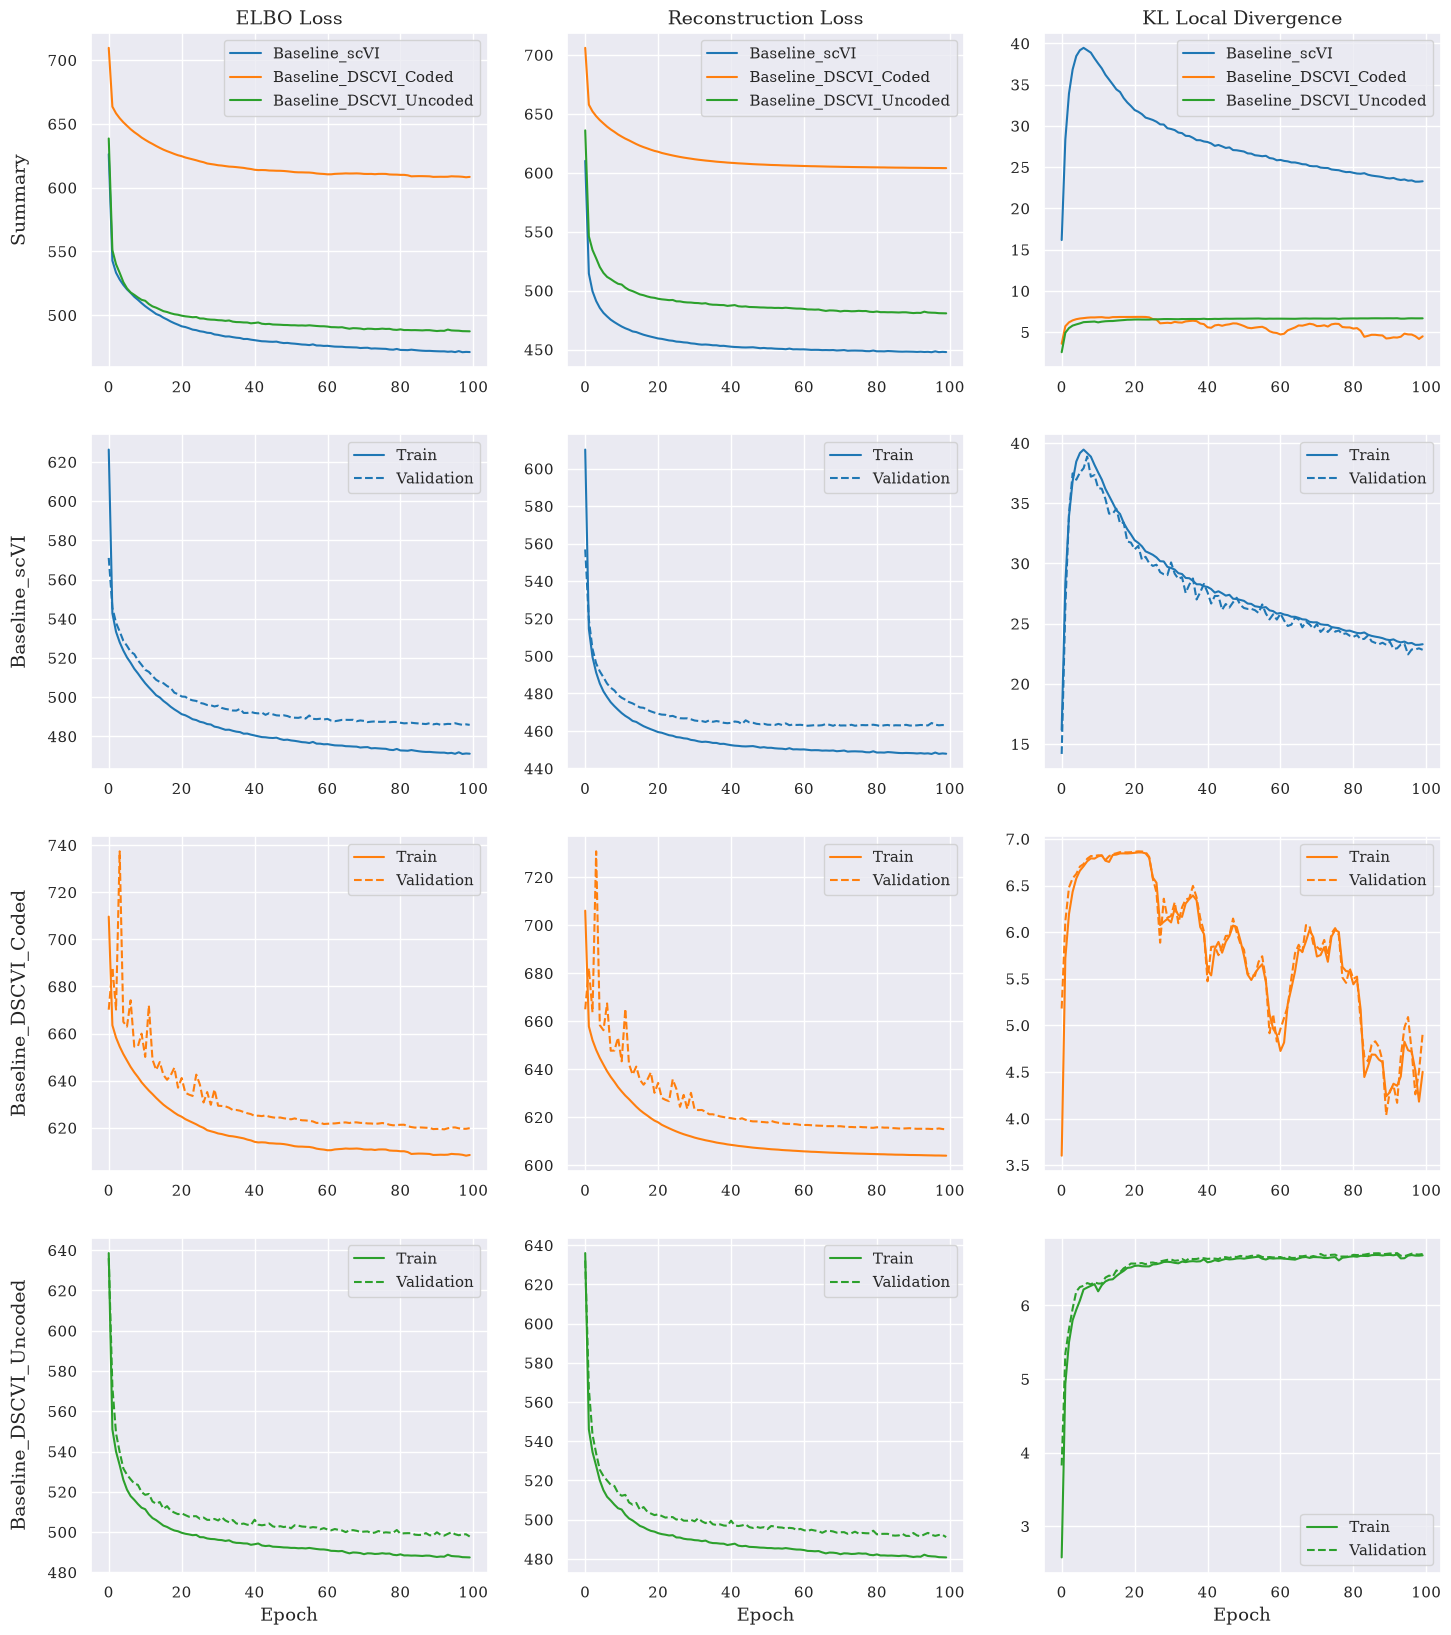

In [40]:
plot_loss_metrics(models_for_loss, model_name=f"{CONT_MODEL_NAME}_vs_{MODEL_NAME}_vs_{UNCODED_MODEL_NAME}", show=False)

## PLOT Tables for Loss Metrics

In [95]:
import pandas as pd
import numpy as np

def extract_metrics(models):
    """
    Extract reconstruction and KL divergence metrics from a dictionary of models.
    Adds a 'Change' column (absolute difference) and 'Change (%)' column
    (absolute change as a percentage of the larger of Start/Final).
    """
    records_recon = []
    records_kl = []

    for name, model in models.items():
        hist = model.history

        # --- Convert history to a single DataFrame ---
        if isinstance(hist, pd.DataFrame):
            df = hist
        elif isinstance(hist, dict):
            all_dfs = all(isinstance(v, (pd.DataFrame, pd.Series)) for v in hist.values())
            if all_dfs:
                concat_dfs = []
                for key, val in hist.items():
                    if isinstance(val, pd.Series):
                        val = val.to_frame(key)
                    elif isinstance(val, pd.DataFrame):
                        if val.shape[1] == 1 and val.columns[0] != key:
                            val = val.rename(columns={val.columns[0]: key})
                    concat_dfs.append(val)
                df = pd.concat(concat_dfs, axis=1)
            else:
                if all(not isinstance(v, (list, tuple, np.ndarray)) for v in hist.values()):
                    print(f"⚠️ Warning: History for '{name}' contains only scalar values. "
                          "Per-epoch history not available. Start and Final will be set to the same value.")
                    df = pd.DataFrame([hist])
                else:
                    try:
                        df = pd.DataFrame(hist)
                    except ValueError:
                        scalar_hist = {k: v for k, v in hist.items() if not isinstance(v, (list, tuple, np.ndarray))}
                        df = pd.DataFrame([scalar_hist])
        elif isinstance(hist, list) and hist and isinstance(hist[0], dict):
            df = pd.DataFrame(hist)
        else:
            raise TypeError(f"Unsupported history type for '{name}': {type(hist)}.")

        # Ensure required columns exist
        required = ['reconstruction_loss_train', 'kl_local_train']
        for col in required:
            if col not in df.columns:
                alt = [c for c in df.columns if col.replace('_train', '') in c and 'train' in c]
                if alt:
                    print(f"ℹ️ Using '{alt[0]}' as '{col}' for '{name}'")
                    df[col] = df[alt[0]]
                else:
                    raise KeyError(f"Missing required column '{col}' in history for '{name}'. "
                                   f"Available: {list(df.columns)}")

        n_epochs = len(df)

        # Reconstruction
        recon_start = df['reconstruction_loss_train'].iloc[0]
        recon_final = df['reconstruction_loss_train'].iloc[-1]
        recon_change = abs(recon_start - recon_final)
        recon_change_pct = (recon_change / max(recon_start, recon_final) * 100) if max(recon_start, recon_final) != 0 else float('nan')

        # KL
        kl_start = df['kl_local_train'].iloc[0]
        kl_final = df['kl_local_train'].iloc[-1]
        kl_change = abs(kl_start - kl_final)
        kl_change_pct = (kl_change / max(kl_start, kl_final) * 100) if max(kl_start, kl_final) != 0 else float('nan')

        # ELBO
        if 'elbo_train' in df.columns:
            elbo = df['elbo_train'].iloc[-1]
        elif 'train_loss' in df.columns:
            elbo = df['train_loss'].iloc[-1]
        else:
            elbo = float('nan')
            print(f"⚠️ Warning: No ELBO or train_loss column for '{name}'; using NaN.")

        records_recon.append({
            'Model': name,
            'Epochs': n_epochs,
            'Start': round(recon_start, 2),
            'Final': round(recon_final, 2),
            'Change': round(recon_change, 2),
            'Change (%)': round(recon_change_pct, 2),
            'ELBO (train)': round(elbo, 2)
        })

        records_kl.append({
            'Model': name,
            'Epochs': n_epochs,
            'Start': round(kl_start, 2),
            'Final': round(kl_final, 2),
            'Change': round(kl_change, 2),
            'Change (%)': round(kl_change_pct, 2),
            'ELBO (train)': round(elbo, 2)
        })

    df_recon = pd.DataFrame(records_recon)
    df_kl = pd.DataFrame(records_kl)

    return {'reconstruction': df_recon, 'kl': df_kl}


def print_metrics_tables(models, markdown=True):
    """
    Print the metrics tables nicely (either as plain text or Markdown).
    """
    metrics = extract_metrics(models)
    for key, df in metrics.items():
        print(f"\n## {key.capitalize()} Metrics\n")
        if markdown:
            print(df.to_markdown(index=False))
        else:
            print(df.to_string(index=False))

In [42]:
coded_model.history["elbo_validation"]

,elbo_validation
epoch,
0,670.134094
1,688.11615
2,670.194519
3,737.356018
4,664.98645
...,...
95,620.170593
96,619.807373
97,619.577515


In [43]:
models = {
    "scVI": cont_model,
    "Uncoded dSCVI": uncoded_model,
    "Late Coded dSCVI": coded400_model,
    "Early Coded dSCVI": test_model,
    "Coded dSCVI": coded_model,
}
metrics = extract_metrics(models)
print_metrics_tables(models, markdown=True)   # prints Markdown tables

NameError: name 'coded400_model' is not defined

## Test_model with 5 epochs

In [ ]:
G = build_repetition_G(bits_m=N_LATENT, r=5)
DSCVI.setup_anndata(adata, layer="counts")
test_model = DSCVI(adata, n_latent=N_LATENT, coded_key=False,
                          n_hidden=128, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')
test_model.train(
        max_epochs=5,
        early_stopping=True,
        # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
        plan_kwargs={"lr": LR}
    )

In [ ]:
test_res = evaluate_posterior_predictive(test_model, n_samples=3, batch_size=32)
print(f"Coded DSCVI global pearson: {test_model['global_pearson']:.4f}")

In [ ]:
MODEL_NAME = register_model("5 DSCVI Coded") # The model we will be training
my_file = Path(model_path(MODEL_NAME))
if my_file.exists():
    coded5_model = DSCVI.load(my_file, adata=adata)
else:
    # Setup AnnData for the coded model (same data, no batch)
    DSCVI.setup_anndata(adata, layer="counts")
    coded5_model = DSCVI(adata, n_latent=N_LATENT, n_code=N_CODE, G=G, coded_key=True,
                        n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')
    # Train with the same number of epochs
    coded5_model.train(
        max_epochs=5,
        early_stopping=True,
        # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
        plan_kwargs={"lr": LR}
    )
    # Save model
    save_model(coded5_model, MODEL_NAME)

## Test_model with 400 epochs

In [ ]:
MODEL_NAME = register_model("400 DSCVI Coded") # The model we will be training

In [ ]:
G = build_repetition_G(N_LATENT, CODE_RATE)

In [ ]:
my_file = Path(model_path(MODEL_NAME))
if my_file.exists():
    coded400_model = DSCVI.load(my_file, adata=adata)
else:
    # Setup AnnData for the coded model (same data, no batch)
    DSCVI.setup_anndata(adata, layer="counts")
    coded400_model = DSCVI(adata, n_latent=N_LATENT, n_code=N_CODE, G=G, coded_key=True,
                        n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')
    # Train with the same number of epochs
    coded400_model.train(
        max_epochs=400,
        early_stopping=True,
        # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
        plan_kwargs={"lr": LR}
    )
    # Save model
    # model_dir = os.path.join(save_dir, "scvi_model_coded_test_3")
    # coded_model.save(model_dir, overwrite=True)
    save_model(coded400_model, MODEL_NAME)

## Investigate KL Divergence ?


In [ ]:
test_model.history.keys()

In [ ]:
test_model.history["elbo_train"]

In [ ]:
test_model.history["train_loss"]

In [ ]:
test_model.history["kl_weight"]

## Bit probabilities

In [ ]:
qi = test_model.get_latent_representation(give_mean=True)

In [ ]:
print(qi.mean(axis=0))

In [ ]:
print(qi.std(axis=0))

In [ ]:
print((qi>0.9).mean(axis=1))

In [ ]:
test_model.history.keys()

In [ ]:
test_model.history["kl_local_train"]

In [ ]:
# Get a batch of real cells from your trained model's data loader
coded_model.module.eval()
test_loader = coded_model._make_data_loader(adata=adata, batch_size=256)
batch = next(iter(test_loader))
x_batch = batch[REGISTRY_KEYS.X_KEY]

In [ ]:
with torch.no_grad():
    inf_out = coded_model.module.inference(x_batch, batch_index=batch[REGISTRY_KEYS.BATCH_KEY])
    qz = inf_out[MODULE_KEYS.QZ_KEY]
    qi = qz.probs if isinstance(qz, Bernoulli) else qz

In [ ]:
# So this is the p(z|c) since it has dimension 100
qz
# Bernoulli(probs: torch.Size([256, 100]))
# type torch.distributions.bernoulli.Bernoulli
len(qi[0])
# 256 lists of length 100
# len 256
# type torch.Tensor

In [ ]:
# p(z|c) - dimensions are good
samples = coded_model.get_latent_representation(adata, return_dist=True)
len(samples[0]), len(samples[1]) # (128, 128)
len(samples[0][0]) # 100

In [ ]:
# p(m|x) - dimensions are correct
samples2 = coded_model.get_latent_representation(adata, return_dist=False, give_mean=True)

In [ ]:
(samples2[0] == samples2[1]).sum() # np.int64(546)

In [ ]:
len(samples2[0]), len(samples2[1]) # (128, 128)

In [ ]:
samples2[0] # 10

In [ ]:
samples_bit = np.where(samples2[0] > 0.5, 1, 0)

## PLOT Bit distribution

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_bit_distributions(models, adata,
                           save=True, show=True, model_name="bit_distributions"):
    """
    Overlaid KDE of bit probabilities (left) and stacked horizontal bar
    of hard‑thresholded bit counts (right) for all models.

    Parameters
    ----------
    models : dict
        Dictionary of {model_label: model_object}. Each model must have
        a method `.get_latent_representation(adata, return_dist=False, give_mean=True)`
        that returns a numpy array of shape (n_cells, n_latent_bits).
    adata : AnnData
        The data to pass to `get_latent_representation`.
    save : bool
        Whether to save the figure.
    show : bool
        Whether to display the figure.
    model_name : str
        Base name used for the saved file (appended with "_bit_distributions").
    """
    n_models = len(models)
    labels = list(models.keys())

    # --- Color palette ---
    palette = plt.cm.tab10.colors if n_models <= 10 else plt.cm.tab20.colors
    model_colors = {label: palette[i % len(palette)] for i, label in enumerate(labels)}

    # --- Prepare data: probabilities and counts for each model ---
    prob_data = {}
    count_data = {}  # will store {model: (count_0, count_1)}
    for label, model in models.items():
        probs = model.get_latent_representation(
            adata, return_dist=False, give_mean=True
        )  # shape (n_cells, n_latent)
        probs_flat = probs.flatten()
        bits = (probs > 0.5).astype(int)
        counts = np.bincount(bits.flatten(), minlength=2)  # [zeros, ones]
        prob_data[label] = probs_flat
        count_data[label] = (counts[0], counts[1])

    # --- Academic font settings ---
    with plt.rc_context({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Serif'],
        'font.size': 12,
        'axes.labelsize': 13,
        'axes.titlesize': 14,
        'legend.fontsize': 11,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
    }):
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), squeeze=False)
        ax0, ax1 = axes[0, 0], axes[0, 1]

        # ----- Left plot: overlaid KDEs with shaded areas -----
        for label in labels:
            color = model_colors[label]
            sns.kdeplot(prob_data[label], fill=True, ax=ax0,
                        color=color, linewidth=2, label=label,
                        clip=(0, 1), alpha=0.3)  # alpha for transparency
        ax0.set_xlim(0, 1)
        ax0.set_title("Bit Activation Density")
        ax0.set_xlabel("P(z=1|c)")
        # Remove y‑axis label and ticks
        ax0.set_ylabel("")
        ax0.set_yticks([])
        ax0.legend()

        # ----- Right plot: horizontal stacked bar with percentages -----
        # Reverse order so first model appears at the top
        labels_rev = list(reversed(labels))
        # Prepare counts in reversed order
        zeros = [count_data[label][0] for label in labels_rev]
        ones = [count_data[label][1] for label in labels_rev]
        totals = [z + o for z, o in zip(zeros, ones)]

        # Compute percentages
        zeros_pct = [z / total * 100 for z, total in zip(zeros, totals)]
        ones_pct = [o / total * 100 for o, total in zip(ones, totals)]

        y_pos = np.arange(len(labels_rev))

        # Plot bars using percentages
        bar_zero = ax1.barh(y_pos, zeros_pct, color="indianred", label="0")
        bar_one = ax1.barh(y_pos, ones_pct, left=zeros_pct, color="seagreen", label="1")

        # Set y‑axis tick labels (model names in reversed order)
        ax1.set_yticks(y_pos)
        ax1.set_yticklabels(labels_rev, fontsize=13)
        ax1.set_title("Information Bit Split")
        ax1.set_xlabel("Percentage of bits")
        ax1.set_ylabel("")
        ax1.set_xlim(0, 100)
        # Set x‑ticks to percentages
        ax1.set_xticks(np.arange(0, 101, 20))
        ax1.set_xticklabels([f"{x}%" for x in np.arange(0, 101, 20)])

        # Annotate each segment with its percentage
        for i, (z_pct, o_pct, total) in enumerate(zip(zeros_pct, ones_pct, totals)):
            # Zero segment annotation (if space)
            if z_pct > 5:
                ax1.text(z_pct/2, i, f"{z_pct:.1f}%", ha='center', va='center',
                         color='white', fontsize=10, fontweight='bold')
            # One segment annotation (if space)
            if o_pct > 5:
                ax1.text(z_pct + o_pct/2, i, f"{o_pct:.1f}%", ha='center', va='center',
                         color='white', fontsize=10, fontweight='bold')
            # Display total count at the end of each bar
            ax1.text(102, i, f"n={total}", ha='left', va='center',
                     fontsize=9, color='gray')

        ax1.legend(loc='lower right')

        # Adjust spacing to prevent label clipping
        plt.tight_layout()

        if save:
            save_path = f"{model_name}_bit_distributions.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved → {save_path}")
        if show:
            plt.show()
        plt.close(fig)
        return fig

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_bit_distributions(models, adata,
                           save=True, show=True, model_name="bit_distributions"):
    """
    Overlaid KDE of bit probabilities (left) and stacked horizontal bar
    of hard‑thresholded bit counts (right) for all models.

    Parameters
    ----------
    models : dict
        Dictionary of {model_label: model_object}. Each model must have
        a method `.get_latent_representation(adata, return_dist=False, give_mean=True)`
        that returns a numpy array of shape (n_cells, n_latent_bits).
    adata : AnnData
        The data to pass to `get_latent_representation`.
    save : bool
        Whether to save the figure.
    show : bool
        Whether to display the figure.
    model_name : str
        Base name used for the saved file (e.g., "comparison").
        The full path is built via `plot_path('bit_distributions', model_name=model_name)`.
    """
    n_models = len(models)
    labels = list(models.keys())

    # --- Color palette ---
    palette = plt.cm.tab10.colors if n_models <= 10 else plt.cm.tab20.colors
    model_colors = {label: palette[i % len(palette)] for i, label in enumerate(labels)}

    # --- Prepare data: probabilities and counts for each model ---
    prob_data = {}
    count_data = {}  # will store {model: (count_0, count_1)}
    for label, model in models.items():
        probs = model.get_latent_representation(
            adata, return_dist=False, give_mean=True
        )  # shape (n_cells, n_latent)
        probs_flat = probs.flatten()
        bits = (probs > 0.5).astype(int)
        counts = np.bincount(bits.flatten(), minlength=2)  # [zeros, ones]
        prob_data[label] = probs_flat
        count_data[label] = (counts[0], counts[1])

    # --- Academic font settings ---
    with plt.rc_context({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Serif'],
        'font.size': 12,
        'axes.labelsize': 13,
        'axes.titlesize': 14,
        'legend.fontsize': 11,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
    }):
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), squeeze=False)
        ax0, ax1 = axes[0, 0], axes[0, 1]

        # ----- Left plot: overlaid KDEs with shaded areas -----
        for label in labels:
            color = model_colors[label]
            sns.kdeplot(prob_data[label], fill=True, ax=ax0,
                        color=color, linewidth=2, label=label,
                        clip=(0, 1), alpha=0.3)  # semi‑transparent fill
        ax0.set_xlim(0, 1)
        ax0.set_title("Bit Activation Density")
        ax0.set_xlabel("P(z=1|c)")
        ax0.set_ylabel("")          # no y‑label
        ax0.set_yticks([])          # no y‑ticks
        ax0.legend()

        # ----- Right plot: horizontal stacked bar with percentages -----
        # Reverse order so first model appears at the top
        labels_rev = list(reversed(labels))
        zeros = [count_data[label][0] for label in labels_rev]
        ones = [count_data[label][1] for label in labels_rev]
        totals = [z + o for z, o in zip(zeros, ones)]

        # Percentages
        zeros_pct = [z / total * 100 for z, total in zip(zeros, totals)]
        ones_pct  = [o / total * 100 for o, total in zip(ones, totals)]

        y_pos = np.arange(len(labels_rev))

        # Plot bars using percentages
        bar_zero = ax1.barh(y_pos, zeros_pct, color="indianred", label="0")
        bar_one  = ax1.barh(y_pos, ones_pct, left=zeros_pct, color="seagreen", label="1")

        ax1.set_yticks(y_pos)
        ax1.set_yticklabels(labels_rev, fontsize=13)
        ax1.set_title("Information Bit Split")
        ax1.set_xlabel("Percentage of bits")
        ax1.set_ylabel("")
        ax1.set_xlim(0, 100)
        ax1.set_xticks(np.arange(0, 101, 20))
        ax1.set_xticklabels([f"{x}%" for x in np.arange(0, 101, 20)])

        # Annotate segments with percentages (only if large enough)
        for i, (z_pct, o_pct, total) in enumerate(zip(zeros_pct, ones_pct, totals)):
            if z_pct > 5:
                ax1.text(z_pct/2, i, f"{z_pct:.1f}%", ha='center', va='center',
                         color='white', fontsize=10, fontweight='bold')
            if o_pct > 5:
                ax1.text(z_pct + o_pct/2, i, f"{o_pct:.1f}%", ha='center', va='center',
                         color='white', fontsize=10, fontweight='bold')
            ax1.text(102, i, f"n={total}", ha='left', va='center',
                     fontsize=9, color='gray')

        ax1.legend(loc='lower right')

        plt.tight_layout()

        if save:
            # Use the same plot_path helper as in the loss‑metrics plot
            try:
                # If plot_path is defined elsewhere, use it
                save_path = plot_path("bit_distributions", model_name=model_name)
            except NameError:
                # Fallback: save in a 'plots/' directory
                import os
                os.makedirs("plots", exist_ok=True)
                save_path = f"plots/{model_name}_bit_distributions.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved → {save_path}")
        if show:
            plt.show()
        plt.close(fig)
        return fig

In [ ]:
models = {
    "scVI": cont_model,
    "Early Coded DSCVI": test_model,
    "Late Coded DSCVI": coded400_model,
      "Coded DSCVI": coded_model,
      "Uncoded DSCVI": uncoded_model
  }
plot_bit_distributions(models, adata, model_name="comparison-400", show=False)

In [ ]:
models = {
    "scVI": cont_model,
    # "Early Coded DSCVI": test_model,
      "Coded DSCVI": coded_model,
      "Uncoded DSCVI": uncoded_model
  }
plot_bit_distributions(models, adata, model_name="comparison", show=False)

## PLOT UMAP

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from typing import Dict, List, Tuple, Optional, Callable, Union

# Assume DEFAULT_MODEL_NAME and plot_path are defined elsewhere
DEFAULT_MODEL_NAME = "model"
def plot_path(name: str, model_name: str = DEFAULT_MODEL_NAME) -> str:
    return f"{name}_{model_name}.png"


def _extract_latent(obj, adata, extractor: Optional[Callable] = None) -> np.ndarray:
    if isinstance(obj, np.ndarray):
        return obj
    if extractor is not None:
        latent = extractor(obj, adata)
    elif hasattr(obj, 'get_latent_representation'):
        latent = obj.get_latent_representation(adata, return_dist=False, give_mean=True)
    else:
        raise TypeError(f"Object of type {type(obj)} cannot be used as latent.")
    if hasattr(latent, 'detach'):
        latent = latent.detach().cpu().numpy()
    elif hasattr(latent, 'numpy'):
        latent = latent.numpy()
    return np.asarray(latent)


def plot_umap_comparison(
    latents_or_models: Dict[str, Union[np.ndarray, object]],
    adata,
    color_keys: List[str] = ("cell_type", "donor", "cell_source"),
    model_name: str = DEFAULT_MODEL_NAME,
    max_legend_categories: int = 20,
    extractor: Optional[Callable] = None,
    save: bool = True,
    show: bool = True,
    figsize_factor: Tuple[float, float] = (6.0, 5.5),
) -> plt.Figure:
    """
    Grid of UMAPs: one row per latent space, one column per metadata field.
    Axis labels only on bottom row and rightmost column; row labels on left;
    column titles on top; legends grouped at the bottom under each column.
    """
    if umap is None:
        raise ImportError("umap-learn is not installed.")

    color_keys = list(color_keys)
    n_rows = len(latents_or_models)
    n_cols = len(color_keys)

    # Extract latents
    latents = {}
    for label, obj in latents_or_models.items():
        latents[label] = _extract_latent(obj, adata, extractor)

    # --- Precompute legend data per column ---
    legend_data = []  # list of (handles, labels, title, ncol) or None
    for key in color_keys:
        categories = pd.Categorical(adata.obs[key])
        n_cat = len(categories.categories)
        if n_cat <= max_legend_categories:
            cmap = plt.get_cmap("tab20", max(n_cat, 1))
            handles = [
                plt.Line2D([0], [0], marker="o", color="w",
                           markerfacecolor=cmap(i), markersize=6)
                for i in range(n_cat)
            ]
            # Custom column limits per field
            if key == "cell_source":
                ncol = min(2, n_cat)
            elif key == "donor":
                ncol = min(4, n_cat)
            else:
                ncol = min(3, n_cat)
            legend_data.append((handles, list(categories.categories), key, ncol))
        else:
            legend_data.append(None)

    # --- Create figure with increased font sizes ---
    with plt.rc_context({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Serif'],
        'font.size': 16,               # was 11 → +5
        'axes.labelsize': 18,          # was 13
        'axes.titlesize': 19,          # was 14
        'legend.fontsize': 15,         # was 10
        'xtick.labelsize': 16,         # was 11
        'ytick.labelsize': 16,         # was 11
    }):
        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(figsize_factor[0] * n_cols, figsize_factor[1] * n_rows),
            squeeze=False
        )

        # --- Plot each subplot ---
        for row_idx, (label, latent) in enumerate(latents.items()):
            embedding = umap.UMAP().fit_transform(latent)

            for col_idx, key in enumerate(color_keys):
                ax = axes[row_idx, col_idx]

                categories = pd.Categorical(adata.obs[key])
                n_cat = len(categories.categories)
                cmap = plt.get_cmap("tab20", max(n_cat, 1))

                ax.scatter(
                    embedding[:, 0], embedding[:, 1],
                    s=2, alpha=0.6,
                    c=categories.codes, cmap=cmap
                )

                # Axis labels only on edges
                if row_idx == n_rows - 1:
                    ax.set_xlabel("UMAP1")
                    ax.tick_params(labelbottom=True)
                else:
                    ax.set_xlabel("")
                    ax.tick_params(labelbottom=False)

                if col_idx == n_cols - 1:
                    ax.set_ylabel("UMAP2")
                    ax.yaxis.set_label_position('right')
                    ax.tick_params(labelleft=False, labelright=True)
                else:
                    ax.set_ylabel("")
                    ax.tick_params(labelleft=False)

                # Titles only on top row
                ax.set_title(key if row_idx == 0 else "")

        # --- Row labels (model names) on the left ---
        for row_idx, label in enumerate(latents.keys()):
            ax_left = axes[row_idx, 0]
            ax_left.set_ylabel(
                label, rotation=90, labelpad=20,
                horizontalalignment='center', verticalalignment='center',
                fontsize=19              # was 14 → +5
            )

        # --- Adjust layout with space for legends ---
        plt.subplots_adjust(
            left=0.15,
            right=0.95,
            top=0.88,
            bottom=0.25,
            wspace=0.05,
            hspace=0.05
        )

        # --- Place legends below each column, just below the x-axis ---
        for col_idx, data in enumerate(legend_data):
            if data is None:
                continue
            handles, labels, title, ncol = data
            bottom_ax = axes[-1, col_idx]
            bbox = bottom_ax.get_position()
            fig.legend(
                handles, labels,
                title=title,
                loc='upper center',
                bbox_to_anchor=(bbox.x0 + bbox.width/2, bbox.y0 - 0.10),
                fontsize=15,             # legend font (already set via rc but explicit)
                title_fontsize=16,       # was 11 → +5
                ncol=ncol,
                frameon=True,
                borderaxespad=0.0
            )

        if save:
            path = plot_path("umap_comparison", model_name=model_name)
            path = path.rsplit('.', 1)[0] + '.png'
            plt.savefig(path, dpi=300, bbox_inches='tight')
            print(f"Saved -> {path}")
        if show:
            plt.show()
        plt.close(fig)
        return fig

In [ ]:
models = {
    "scVI": cont_model,
    "Early Coded DSCVI": test_model,
    "Late Coded DSCVI": coded400_model,
    "Coded DSCVI": coded_model,
    "Uncoded DSCVI": uncoded_model
  }
plot_umap_comparison(models, adata, model_name="umap-comparison-all", show=False)

## PLOT Posterior Predictive Sampling

In [45]:
import torch
import numpy as np
from scipy.stats import pearsonr
from tqdm import tqdm

def get_model_device(model):
    """Get device from the underlying PyTorch module."""
    if hasattr(model, 'module'):
        return next(model.module.parameters()).device
    elif hasattr(model, 'parameters'):
        return next(model.parameters()).device
    else:
        return torch.device('cpu')

def evaluate_posterior_predictive(model, adata=None, indices=None, batch_size=128, n_samples=30):
    """
    Compute posterior predictive correlation metrics.
    Works for both official scvi-tools SCVI and your custom DSCVI.
    """
    dataloader = model._make_data_loader(
        adata=adata if adata is not None else model.adata,
        indices=indices,
        batch_size=batch_size,
        shuffle=False
    )

    all_observed = []
    all_imputed = []
    device = get_model_device(model)

    with torch.inference_mode():
        for tensors in tqdm(dataloader, desc="Sampling posterior"):
            tensors = {k: v.to(device) for k, v in tensors.items() if torch.is_tensor(v)}

            # Detect the count key
            if 'X' in tensors:
                x_obs = tensors['X']
            elif 'x' in tensors:
                x_obs = tensors['x']
            else:
                raise KeyError(f"Available keys: {tensors.keys()}")

            # ---- Unified call via .module.sample() ----
            samples = model.module.sample(
                tensors,
                n_samples=n_samples,
                max_poisson_rate=1e8,
            )

            # ---- Average over MC samples (shape‑agnostic) ----
            if n_samples > 1:
                # scVI returns (n_samples, batch, genes)
                # Your DSCVI returns (batch, genes, n_samples)
                if samples.shape[0] == n_samples:
                    x_imp = samples.mean(dim=0)      # scVI style
                else:
                    x_imp = samples.mean(dim=-1)     # DSCVI style
            else:
                x_imp = samples

            all_observed.append(x_obs.cpu().numpy())
            all_imputed.append(x_imp.cpu().numpy())

    obs = np.concatenate(all_observed, axis=0)
    imp = np.concatenate(all_imputed, axis=0)

    global_corr, _ = pearsonr(obs.flatten(), imp.flatten())

    gene_corrs = []
    for g in range(obs.shape[1]):
        if np.std(obs[:, g]) > 0:
            corr, _ = pearsonr(obs[:, g], imp[:, g])
            gene_corrs.append(corr)
        else:
            gene_corrs.append(np.nan)

    obs_zero = (obs == 0)
    imp_zero = (imp < 0.5)
    zero_acc = np.mean(obs_zero == imp_zero)
    true_zero_rate = np.mean(imp_zero[obs_zero]) if np.sum(obs_zero) > 0 else np.nan

    return {
        'global_pearson': global_corr,
        'gene_pearson_mean': np.nanmean(gene_corrs),
        'gene_pearson_std': np.nanstd(gene_corrs),
        'zero_accuracy': zero_acc,
        'true_zero_rate': true_zero_rate,
        'imputed_matrix': imp,
        'observed_matrix': obs,
    }

In [53]:
models = {
    "scVI": cont_model,
    # "Early Coded DSCVI": coded5_model,
    # "Late Coded DSCVI": coded400_model,
    "Coded DSCVI": coded_model,
    "Uncoded DSCVI": uncoded_model
}

results = {}
final_kls = {}

for name, model in models.items():
    eval_res = evaluate_posterior_predictive(
        model,
        adata=None,
        batch_size=128,
        n_samples=20
    )

    # ---- Get final KL (handle both DSCVI and scVI) ----
    if hasattr(model, 'history'):
        kl_history = model.history
        # Try common keys
        if 'kl_local_train' in kl_history:
            kl_vals = kl_history['kl_local_train']
        elif 'kl_local' in kl_history:
            kl_vals = kl_history['kl_local']
        elif 'elbo_train' in kl_history:
            kl_vals = None
        else:
            kl_vals = None

        if kl_vals is not None:
            if hasattr(kl_vals, 'iloc'):
                final_kl = kl_vals.iloc[-1]
            else:
                final_kl = kl_vals[-1]
            
            # Convert to float
            if hasattr(final_kl, 'item'):
                final_kl = float(final_kl.item())
            elif hasattr(final_kl, 'values'):
                final_kl = float(final_kl.values[0])
            else:
                final_kl = float(final_kl)
        else:
            final_kl = np.nan
    else:
        final_kl = np.nan

    results[name] = eval_res
    final_kls[name] = final_kl

    print(f"{name}: global pearson = {eval_res['global_pearson']:.4f}, final KL = {final_kl:.4f}")

Sampling posterior: 100%|██████████| 146/146 [00:03<00:00, 45.42it/s]


scVI: global pearson = 0.8509, final KL = 23.2894


Sampling posterior: 100%|██████████| 146/146 [00:02<00:00, 54.57it/s]


Coded DSCVI: global pearson = 0.1616, final KL = 4.5013


Sampling posterior: 100%|██████████| 146/146 [00:02<00:00, 52.48it/s]


Uncoded DSCVI: global pearson = 0.2153, final KL = 6.6815


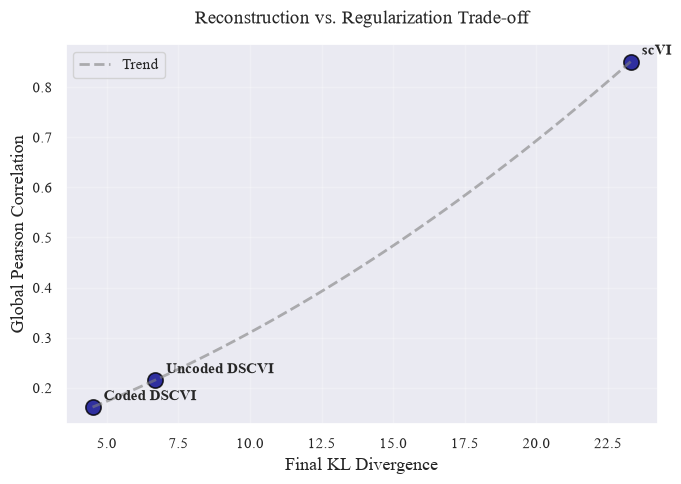

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Extract data ----
names = list(results.keys())
pearsons = np.array([results[n]['global_pearson'] for n in names])
kls = np.array([final_kls[n] for n in names])

# ---- Remove models with NaN KL (e.g., scVI) ----
mask = ~np.isnan(kls)
names_filtered = np.array(names)[mask]
kls_filtered = kls[mask]
pearsons_filtered = pearsons[mask]

# ---- Figure with academic style ----
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(7, 5))

# Scatter points
ax.scatter(kls_filtered, pearsons_filtered, s=120, c='darkblue', alpha=0.8, edgecolors='black', linewidth=1.2)

# Annotate each point with model name
for i, name in enumerate(names_filtered):
    ax.annotate(name, (kls_filtered[i], pearsons_filtered[i]),
                xytext=(8, 5), textcoords='offset points',
                fontsize=11, fontweight='bold')

# ---- Optional: smooth trend line (if ≥3 points) ----
if len(kls_filtered) >= 3:
    try:
        from scipy.interpolate import UnivariateSpline
        # Sort by KL
        idx_sorted = np.argsort(kls_filtered)
        k_sorted = kls_filtered[idx_sorted]
        p_sorted = pearsons_filtered[idx_sorted]
        # Fit a quadratic spline (smoothing factor 0.3)
        spline = UnivariateSpline(k_sorted, p_sorted, k=2, s=0.3)
        x_smooth = np.linspace(k_sorted.min(), k_sorted.max(), 100)
        y_smooth = spline(x_smooth)
        ax.plot(x_smooth, y_smooth, '--', color='gray', alpha=0.6, linewidth=2, label='Trend')
        ax.legend(loc='best')
    except Exception:
        # Fallback: simple line connecting points
        ax.plot(k_sorted, p_sorted, '--', color='gray', alpha=0.6, linewidth=2, label='Trend')
        ax.legend(loc='best')

# ---- Labels and title ----
ax.set_xlabel('Final KL Divergence', fontsize=13)
ax.set_ylabel('Global Pearson Correlation', fontsize=13)
ax.set_title('Reconstruction vs. Regularization Trade‑off', fontsize=14, pad=15)
ax.grid(alpha=0.25)

# ---- Save figure (optional) ----
# Uncomment and adjust path as needed:
# plt.savefig('pearson_vs_kl.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# 5. KL Annealing

## TRAIN LINEAR KL

In [69]:
G = build_repetition_G(N_LATENT, CODE_RATE)

In [ ]:
KL100_MODEL_NAME = register_model("KL100 DSCVI Coded") # The model we will be training
my_file = Path(model_path(MODEL_NAME))
# Setup AnnData for the coded model (same data, no batch)
DSCVI.setup_anndata(adata, layer="counts")
kl100_coded_model = DSCVI(adata, n_latent=N_LATENT, n_code=N_CODE, G=G, coded_key=True,
                    n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')
# Train with the same number of epochs
kl100_coded_model.train(
    max_epochs=MAX_EPOCHS,
    early_stopping=True,
    # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
    plan_kwargs={"lr": LR, "n_epochs_kl_warmup": 100}
)
model_dir = save_dir / "models" / KL100_MODEL_NAME
kl100_coded_model.save(model_dir, overwrite=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[register_model] Warning: 'KL100_DSCVI_Coded' was already registered this session. Re-using it (existing plots for this name will get an auto-incremented suffix, not overwritten).


c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [11:39<00:00,  2.56s/it, v_num=1, train_loss=606] 

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [11:39<00:00,  6.99s/it, v_num=1, train_loss=606]


In [ ]:
KL10_MODEL_NAME = register_model("KL10 DSCVI Coded") # The model we will be training
my_file = Path(model_path(MODEL_NAME))
# Setup AnnData for the coded model (same data, no batch)
DSCVI.setup_anndata(adata, layer="counts")
kl10_coded_model = DSCVI(adata, n_latent=N_LATENT, n_code=N_CODE, G=G, coded_key=True,
                    n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')
# Train with the same number of epochs
kl10_coded_model.train(
    max_epochs=MAX_EPOCHS,
    early_stopping=True,
    # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
    plan_kwargs={"lr": LR, "n_epochs_kl_warmup": 10}
)
model_dir = save_dir / "models" / KL10_MODEL_NAME
kl10_coded_model.save(model_dir, overwrite=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [06:41<00:00,  2.78s/it, v_num=1, train_loss=606]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [06:41<00:00,  4.02s/it, v_num=1, train_loss=606]


In [ ]:
KL20_MODEL_NAME = register_model("KL20 DSCVI Coded") # The model we will be training
my_file = Path(model_path(MODEL_NAME))
# Setup AnnData for the coded model (same data, no batch)
DSCVI.setup_anndata(adata, layer="counts")
kl20_coded_model = DSCVI(adata, n_latent=N_LATENT, n_code=N_CODE, G=G, coded_key=True,
                    n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')
# Train with the same number of epochs
kl20_coded_model.train(
    max_epochs=MAX_EPOCHS,
    early_stopping=True,
    # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
    plan_kwargs={"lr": LR, "n_epochs_kl_warmup": 20}
)
model_dir = save_dir / "models" / KL20_MODEL_NAME
kl20_coded_model.save(model_dir, overwrite=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[register_model] Warning: 'KL20_DSCVI_Coded' was already registered this session. Re-using it (existing plots for this name will get an auto-incremented suffix, not overwritten).


c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [04:49<00:00,  2.65s/it, v_num=1, train_loss=606]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [04:49<00:00,  2.89s/it, v_num=1, train_loss=606]


In [ ]:
KL30_MODEL_NAME = register_model("KL30 DSCVI Coded") # The model we will be training
my_file = Path(model_path(MODEL_NAME))
# Setup AnnData for the coded model (same data, no batch)
DSCVI.setup_anndata(adata, layer="counts")
kl30_coded_model = DSCVI(adata, n_latent=N_LATENT, n_code=N_CODE, G=G, coded_key=True,
                    n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')
# Train with the same number of epochs
kl30_coded_model.train(
    max_epochs=MAX_EPOCHS,
    early_stopping=True,
    # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
    plan_kwargs={"lr": LR, "n_epochs_kl_warmup": 30}
)
model_dir = save_dir / "models" / KL30_MODEL_NAME
kl30_coded_model.save(model_dir, overwrite=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [05:52<00:00,  3.17s/it, v_num=1, train_loss=607]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [05:52<00:00,  3.53s/it, v_num=1, train_loss=607]


In [ ]:
KL50_MODEL_NAME = register_model("KL50 DSCVI Coded") # The model we will be training
my_file = Path(model_path(MODEL_NAME))
# Setup AnnData for the coded model (same data, no batch)
DSCVI.setup_anndata(adata, layer="counts")
kl50_coded_model = DSCVI(adata, n_latent=N_LATENT, n_code=N_CODE, G=G, coded_key=True,
                    n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')
# Train with the same number of epochs
kl50_coded_model.train(
    max_epochs=MAX_EPOCHS,
    early_stopping=True,
    # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
    plan_kwargs={"lr": LR, "n_epochs_kl_warmup": 30}
)
model_dir = save_dir / "models" / KL50_MODEL_NAME
kl50_coded_model.save(model_dir, overwrite=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [06:47<00:00,  3.98s/it, v_num=1, train_loss=607]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [06:47<00:00,  4.08s/it, v_num=1, train_loss=607]


In [92]:
CODED_MODEL_NAME = register_model("Baseline DSCVI Coded") # The model we will be training
my_file = Path(model_path(MODEL_NAME))
# Setup AnnData for the coded model (same data, no batch)
DSCVI.setup_anndata(adata, layer="counts")
coded_model = DSCVI(adata, n_latent=N_LATENT, n_code=N_CODE, G=G, coded_key=True,
                    n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')
# Train with the same number of epochs
coded_model.train(
    max_epochs=MAX_EPOCHS,
    early_stopping=True,
    # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
    plan_kwargs={"lr": LR}
)
model_dir = save_dir / "models" / CODED_MODEL_NAME
coded_model.save(model_dir, overwrite=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[register_model] Warning: 'Baseline_DSCVI_Coded' was already registered this session. Re-using it (existing plots for this name will get an auto-incremented suffix, not overwritten).


c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [04:46<00:00,  2.95s/it, v_num=1, train_loss=605]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [04:46<00:00,  2.86s/it, v_num=1, train_loss=605]


Saved -> /content/drive/MyDrive/TFG\plots\kl_linear_coded_loss_metrics_3.png


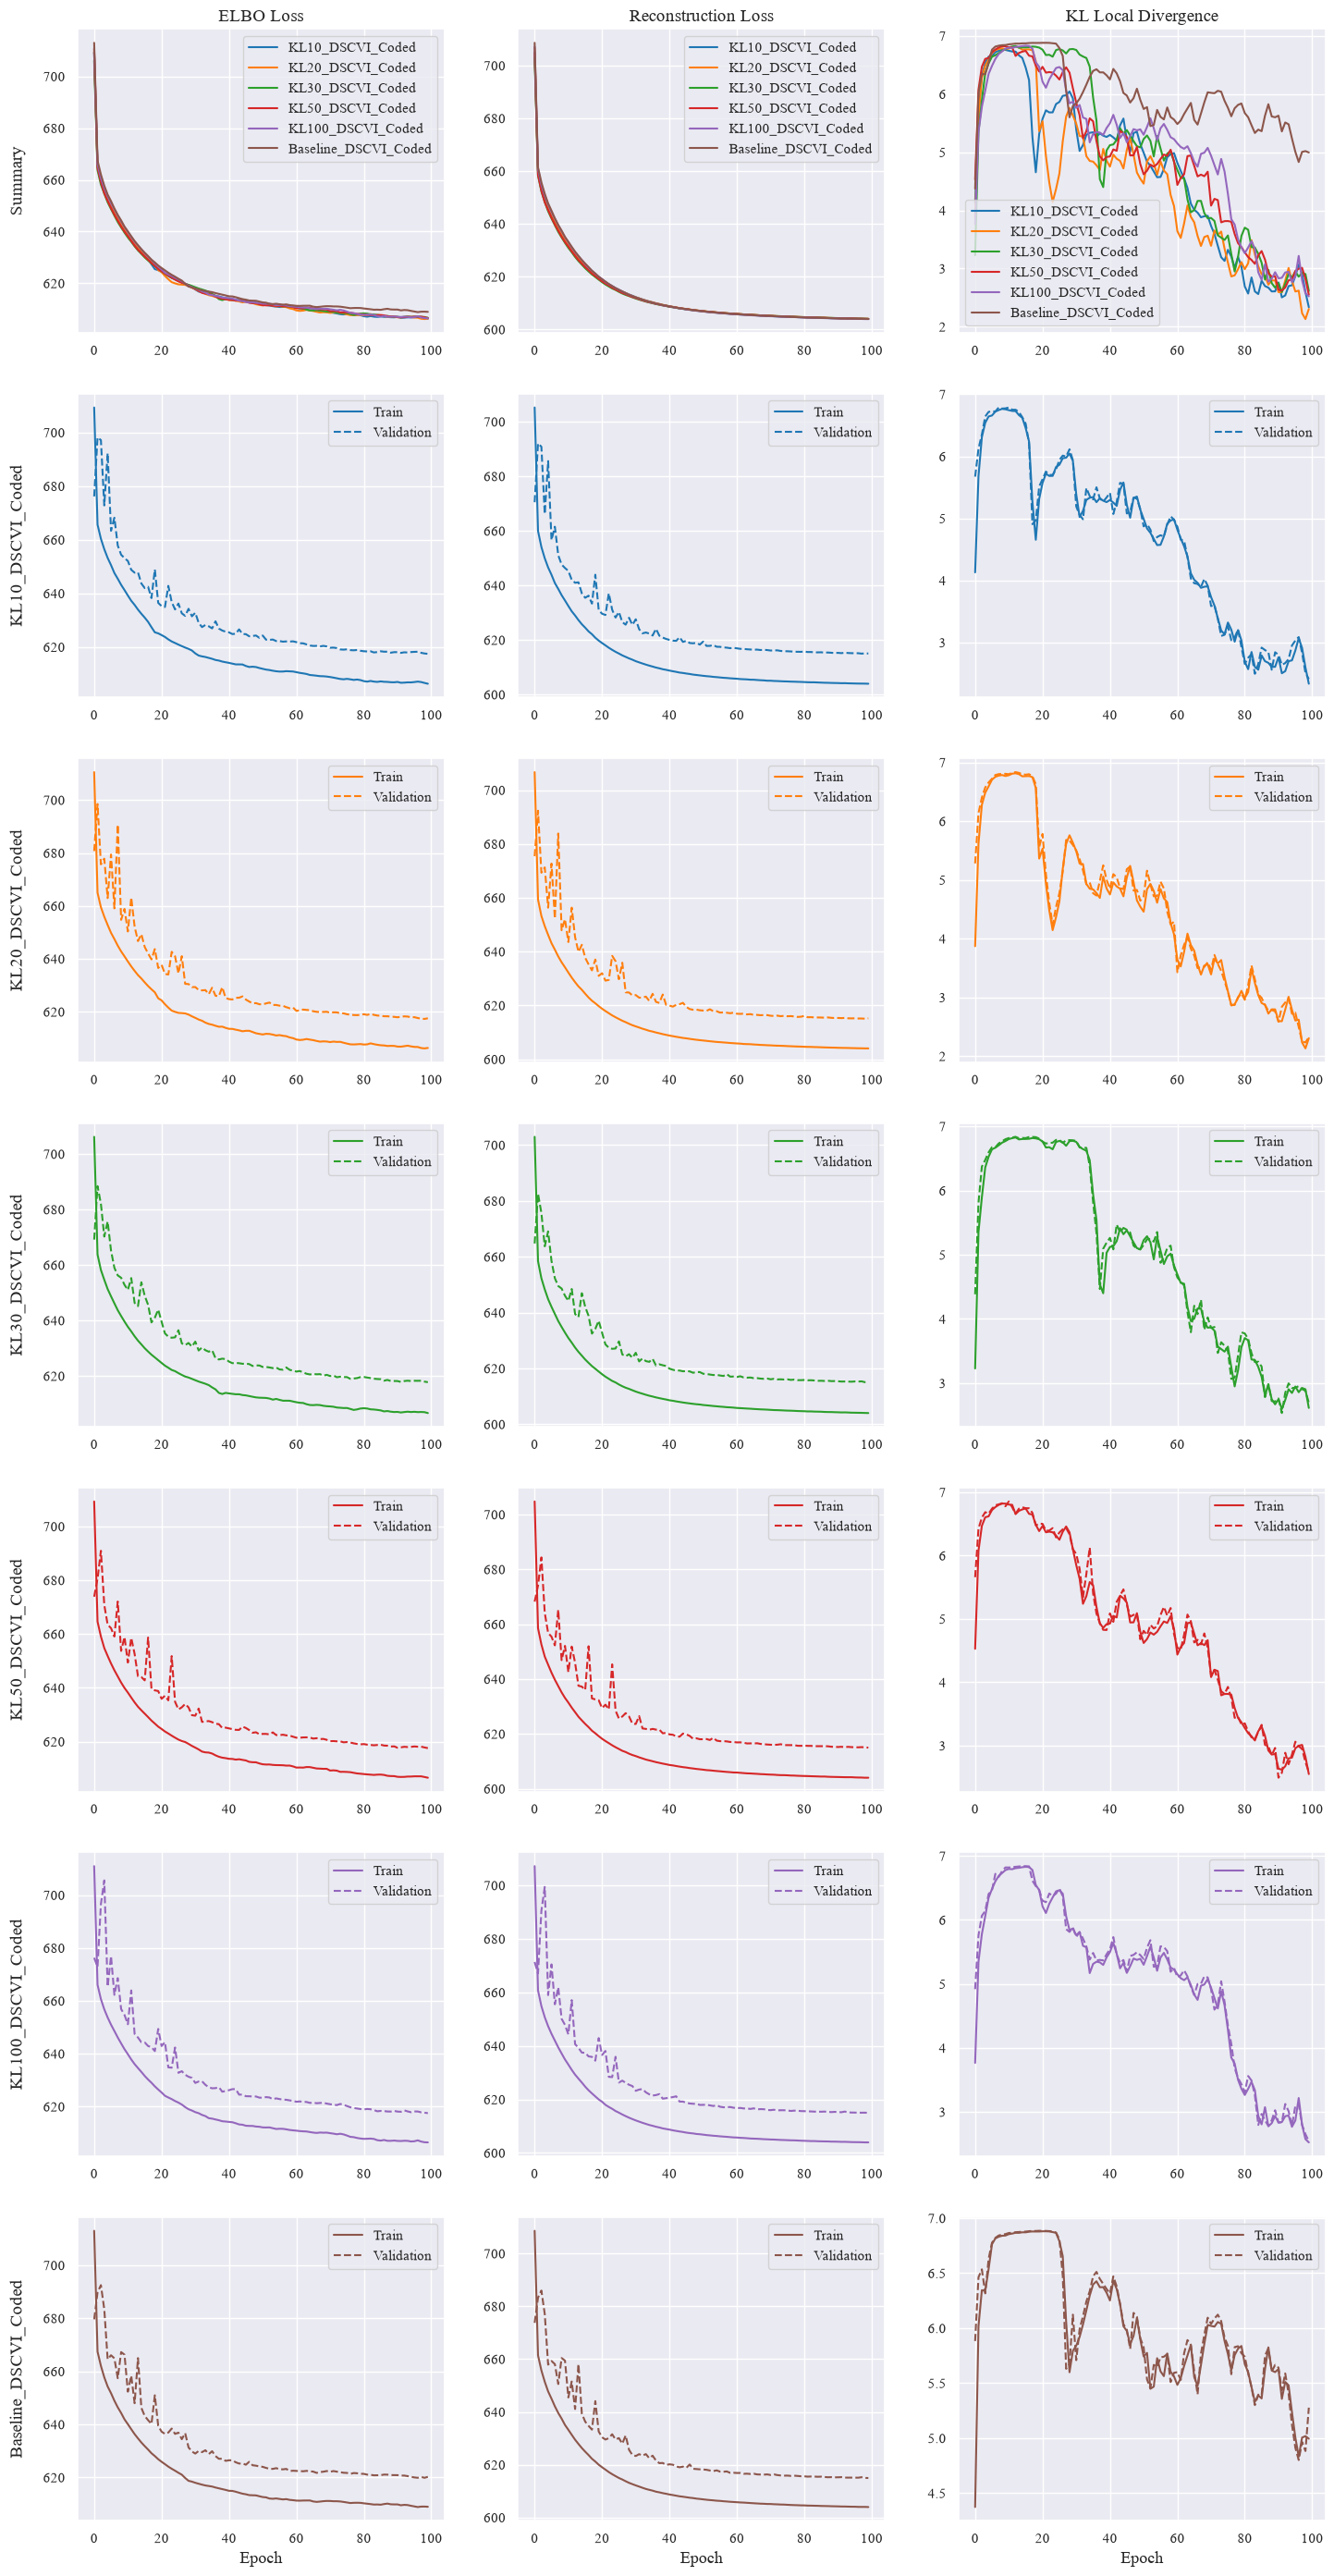

In [93]:
models_for_loss = {
    KL10_MODEL_NAME: kl10_coded_model,
    KL20_MODEL_NAME: kl20_coded_model,
    KL30_MODEL_NAME: kl30_coded_model,
    KL50_MODEL_NAME: kl50_coded_model,
    KL100_MODEL_NAME: kl100_coded_model,
    CODED_MODEL_NAME: coded_model
    
}

plot_loss_metrics(models_for_loss, model_name="kl_linear_coded", show=False)

In [98]:
metrics = extract_metrics(models_for_loss)
print_metrics_tables(models_for_loss, markdown=True)   # prints Markdown tables


## Reconstruction Metrics

| Model                |   Epochs |   Start |   Final |   Change |   Change (%) |   ELBO (train) |
|:---------------------|---------:|--------:|--------:|---------:|-------------:|---------------:|
| KL10_DSCVI_Coded     |      100 |  705.21 |  603.96 |   101.26 |        14.36 |         606.29 |
| KL20_DSCVI_Coded     |      100 |  706.67 |  604.03 |   102.64 |        14.52 |         606.33 |
| KL30_DSCVI_Coded     |      100 |  702.96 |  604.02 |    98.94 |        14.08 |         606.63 |
| KL50_DSCVI_Coded     |      100 |  704.76 |  604.01 |   100.75 |        14.3  |         606.56 |
| KL100_DSCVI_Coded    |      100 |  707.19 |  603.94 |   103.25 |        14.6  |         606.46 |
| Baseline_DSCVI_Coded |      100 |  708.62 |  603.96 |   104.66 |        14.77 |         608.95 |

## Kl Metrics

| Model                |   Epochs |   Start |   Final |   Change |   Change (%) |   ELBO (train) |
|:---------------------|---------:|--------:|--------:|---------:

In [99]:
models_kl_linear = {
    KL10_MODEL_NAME: kl10_coded_model,
    KL20_MODEL_NAME: kl20_coded_model,
    KL30_MODEL_NAME: kl30_coded_model,
    KL50_MODEL_NAME: kl50_coded_model,
    KL100_MODEL_NAME: kl100_coded_model,
    CODED_MODEL_NAME: coded_model
    
}

In [100]:
results = {}
final_kls = {}

for name, model in models_kl_linear.items():
    eval_res = evaluate_posterior_predictive(
        model,
        adata=None,
        batch_size=128,
        n_samples=20
    )

    # ---- Get final KL (handle both DSCVI and scVI) ----
    if hasattr(model, 'history'):
        kl_history = model.history
        # Try common keys
        if 'kl_local_train' in kl_history:
            kl_vals = kl_history['kl_local_train']
        elif 'kl_local' in kl_history:
            kl_vals = kl_history['kl_local']
        elif 'elbo_train' in kl_history:
            kl_vals = None
        else:
            kl_vals = None

        if kl_vals is not None:
            if hasattr(kl_vals, 'iloc'):
                final_kl = kl_vals.iloc[-1]
            else:
                final_kl = kl_vals[-1]
            
            # Convert to float
            if hasattr(final_kl, 'item'):
                final_kl = float(final_kl.item())
            elif hasattr(final_kl, 'values'):
                final_kl = float(final_kl.values[0])
            else:
                final_kl = float(final_kl)
        else:
            final_kl = np.nan
    else:
        final_kl = np.nan

    results[name] = eval_res
    final_kls[name] = final_kl

    print(f"{name}: global pearson = {eval_res['global_pearson']:.4f}, final KL = {final_kl:.4f}")

Sampling posterior: 100%|██████████| 146/146 [00:06<00:00, 24.12it/s]


KL10_DSCVI_Coded: global pearson = 0.1550, final KL = 2.3353


Sampling posterior: 100%|██████████| 146/146 [00:03<00:00, 44.55it/s]


KL20_DSCVI_Coded: global pearson = 0.1580, final KL = 2.3051


Sampling posterior: 100%|██████████| 146/146 [00:02<00:00, 52.30it/s]


...

KL50_DSCVI_Coded: global pearson = 0.1606, final KL = 2.5509


Sampling posterior: 100%|██████████| 146/146 [00:02<00:00, 49.05it/s]


KL100_DSCVI_Coded: global pearson = 0.1594, final KL = 2.5234


Sampling posterior: 100%|██████████| 146/146 [00:03<00:00, 46.47it/s]


Baseline_DSCVI_Coded: global pearson = 0.1613, final KL = 4.9953


## TRAIN CYCLICAL KL

In [103]:
import math
from scvi.train import TrainingPlan

class CyclicalKLTrainingPlan(TrainingPlan):
    def __init__(self, module, n_epochs_per_cycle=50, ratio=0.5, **kwargs):
        super().__init__(module, **kwargs)
        self.n_epochs_per_cycle = n_epochs_per_cycle
        self.ratio = ratio  # fraction of cycle spent increasing KL (e.g. 0.5)

    @property
    def kl_weight(self):
        # current position within the current cycle (0 to 1)
        cycle_position = (self.current_epoch % self.n_epochs_per_cycle) / self.n_epochs_per_cycle
        if cycle_position < self.ratio:
            # ascending part of cycle
            return self.min_kl_weight + (self.max_kl_weight - self.min_kl_weight) * (cycle_position / self.ratio)
        else:
            # plateau at max for the rest of the cycle
            return self.max_kl_weight

In [ ]:

import math
from scvi.train import TrainingPlan

class CyclicalKLTrainingPlan(TrainingPlan):
    def __init__(
        self,
        module,
        n_epochs_per_cycle: int = 50,
        ratio: float = 0.5,
        min_kl_weight: float = 0.0,
        max_kl_weight: float = 1.0,
        **kwargs,
    ):
        self.n_epochs_per_cycle = n_epochs_per_cycle
        self.ratio = ratio
        self.min_kl_weight = min_kl_weight
        self.max_kl_weight = max_kl_weight
        super().__init__(module, **kwargs)

    def on_train_epoch_start(self) -> None:
        """Update kl_weight at the start of every epoch (cyclical schedule)."""
        super().on_train_epoch_start()

        cycle_position = (
            self.current_epoch % self.n_epochs_per_cycle
        ) / self.n_epochs_per_cycle

        if cycle_position < self.ratio:
            # Linearly increase from min → max
            self.kl_weight = self.min_kl_weight + (
                self.max_kl_weight - self.min_kl_weight
            ) * (cycle_position / self.ratio)
        else:
            # Hold at max for the rest of the cycle
            self.kl_weight = self.max_kl_weight

In [114]:
KL50_CYCLICAL_MODEL_NAME = register_model("KL50 Cyclical DSCVI Coded") # The model we will be training
# Setup AnnData for the coded model (same data, no batch)
DSCVI.setup_anndata(adata, layer="counts")
kl50_cyclical_coded_model = DSCVI(adata, n_latent=N_LATENT, n_code=N_CODE, G=G, coded_key=True,
                    n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=BETA, latent_distribution='ber')
# Train with the same number of epochs
kl50_cyclical_coded_model._training_plan_cls=CyclicalKLTrainingPlan
kl50_cyclical_coded_model.train(
    max_epochs=MAX_EPOCHS,
    early_stopping=True,
    plan_kwargs={
        "lr": LR}
)
model_dir = save_dir / "models" / KL50_CYCLICAL_MODEL_NAME
kl50_cyclical_coded_model.save(model_dir, overwrite=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[register_model] Warning: 'KL50_Cyclical_DSCVI_Coded' was already registered this session. Re-using it (existing plots for this name will get an auto-incremented suffix, not overwritten).


c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Justi\Documents\TFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [04:48<00:00,  3.57s/it, v_num=1, train_loss=605]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [04:48<00:00,  2.88s/it, v_num=1, train_loss=605]


In [115]:
kl50_cyclical_coded_model.history["kl_weight"]

,kl_weight
epoch,
0,0.0
1,0.0025
2,0.005
3,0.0075
4,0.01
...,...
95,0.2375
96,0.24
97,0.2425


Saved -> /content/drive/MyDrive/TFG\plots\kl_linear_coded_loss_metrics_4.png


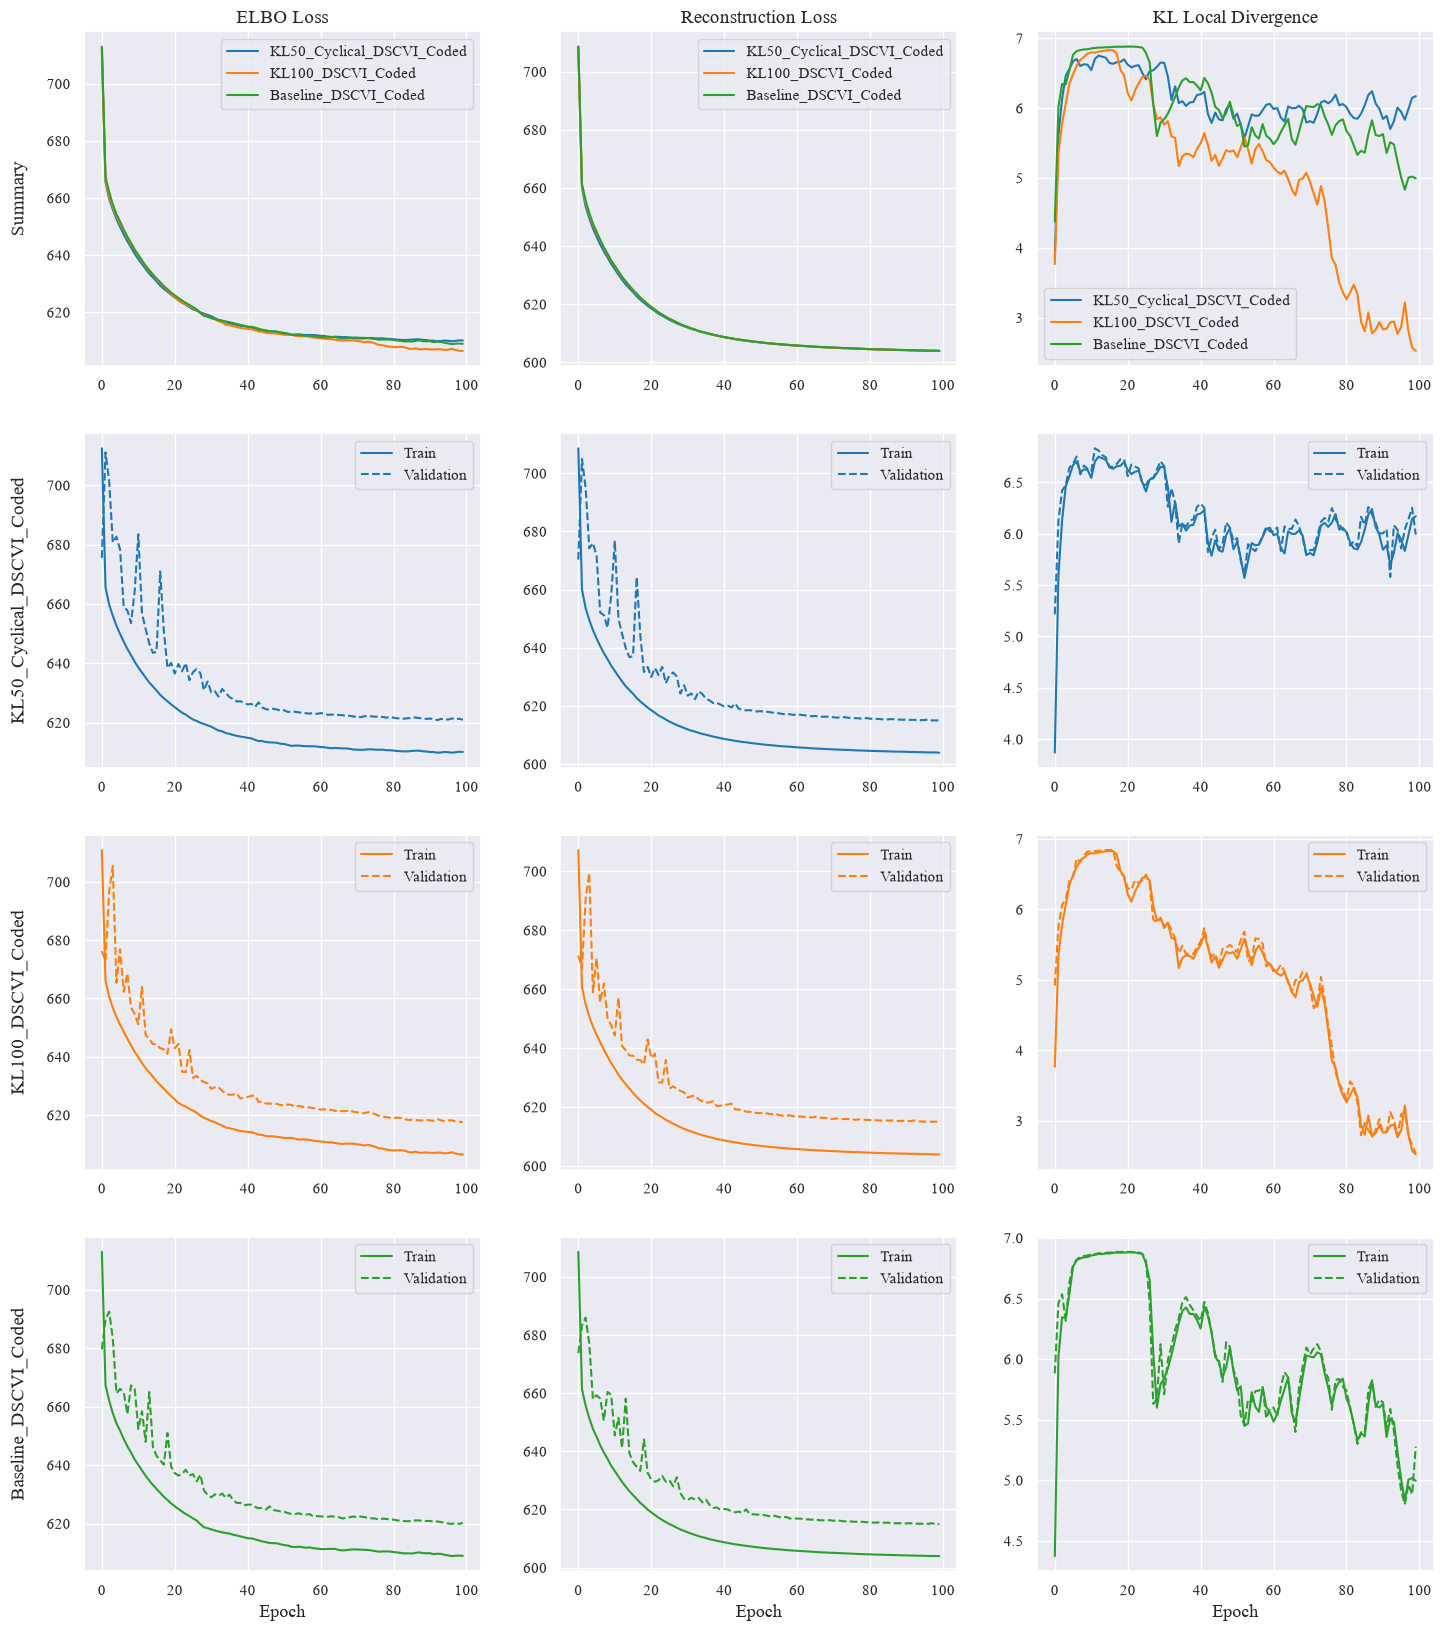

In [116]:
models_for_loss = {
    KL50_CYCLICAL_MODEL_NAME: kl50_cyclical_coded_model,
    KL100_MODEL_NAME: kl100_coded_model,
    CODED_MODEL_NAME: coded_model
    
}

plot_loss_metrics(models_for_loss, model_name="kl_linear_coded", show=False)

# Gridsearch

In [ ]:
results = {}
for beta in [1, 5, 10, 20]:
    for r in [3, 5, 7]:
        name = f"coded_b{beta}_r{r}"
        G = build_repetition_G(bits_m=10, r=r)
        DSCVI.setup_anndata(adata, layer="counts")
        model = DSCVI(adata, n_latent=10, n_code=10*r, G=G, coded_key=True,
                      n_hidden=N_HIDDEN, n_layers=N_LAYERS, beta=beta, latent_distribution='ber')
        model.train(max_epochs=MAX_EPOCHS, early_stopping=True, plan_kwargs={"lr": LR})

        # Store final metrics
        results[name] = {
            "train_loss": model.history["train_loss"].values[-1],
            "elbo_val": model.history["elbo_validation"].values[-1],
            "kl_z": model.history.get("kl_local_train", {}).get("kl_divergence_z", None),
        }
        save_model(model, register_model(name))
        del model
        torch.cuda.empty_cache()  # free GPU memory between runs